# 0. Intro

This notebook documents and simulates the questions we seek to understand through the combination of computational and experimental means in the lab.

As submitted to ESA Europe, the experiment is described as such:

*Title*: Agent and Human Experiments on Search, Information, and Market Asymmetries in Decentralized Economies

*Abstract*: We construct a minimal agent based model of a decentralized, spatial random meetings economy to study search strategy and returns to agglomeration. We conduct experiments on the effects of search costs, information, and market asymmetries. We construct hypotheses based on the agent model and test these results in a calibrated human subjects experiment.

In our economy buyers and sellers search for trading partners over a discrete N x N grid. Agents at the same node form a market and trade using a limit order book. We consider two classes of strategies: (1) a zero intelligence strategy, where search is random and trading follows a budget constrained zero-intelligence strategy; and (2) a zero-intelligence-plus strategy, where both search and trading are guided by a simple opportunity cost model.

In the model individuals start at random locations on the grid and make search and trading decisions each day. Agents earn utility based on trade and an assigned value (cost) schedule, which reinitializes every week. In our baseline condition the model predicts that symmetric buyers and sellers find each other at nodes and then stop searching due to high search costs.  Agents who are still searching then tend to find these market nodes and increase the local market size, potentially creating asymmetries.  Using local price information the local markets then reach a local equilibrium. The modal result is a partial market fragmentation, with several nodes occupied by multiple agents and a relatively high efficiency of trade.

We consider three treatments.  Our first treatment compares symmetric buyers and sellers with asymmetric buyers and sellers.  We hypothesize that the symmetric case will lead to higher efficiency and better price discovery, as well as less variance in the global market efficiency due to market fragmentation.  Our second treatment compares higher search costs to lower search costs by subsidizing search, analogous to an unemployment insurance.  We hypothesize that lower search cost will lead to less market fragmentation in markets with zero-intelligence-plus strategies.  Our third treatment compares local vs. global price information.  We hypothesize that global price information will improve the efficiency of exchange in the long term, but will lead to longer search periods due to higher perceived rewards to search.

We then calibrate our agent-based model to the case of a 4x4 grid with 3 buyers and 3 sellers lasting 25 trading periods to match our anticipated human subject experiment.

In [1]:
import os
import sys

# Data processing
import numpy as np                              # import numpy
import pandas as pd

# Plotting
import matplotlib.pyplot as plt                 # import matplotlib

# Custom packages for simulation
# This works only if notebooks folder is in the "modules" parent folder
sys.path.insert(0, '..') # add modules folder (parent folder) into this notebook's path

# Institution modules
import institutions.dm_bargain as dm_bargain
import institutions.dm_travel as dm_travel

# Environment modules
import environment.dm_agents as dm_agents
import environment.dm_env as env
import environment.env_make_agents as env_make_agents

# Simulation modules
import simulations.dm_sim_period as simulate
import simulations.dm_sim as dm_sim

# Import functions to run experiments
import simulations.dm_sim_experiment as dm_sim_experiment

# Utility modules
import utils.dm_utils as dm_utils
import utils.dm_process_results as dm_process_results
import utils.dm_res_helpers as dm_res_helpers # Extended results module
import utils.dm_stats as dm_stat

# Import notebook helper functions
import utils.nb_helpers as nb_helpers

# Stats models
from scipy.stats import sem

# 1.0 Model Baselines
## 1.1 Bargaining Outcomes
In this section we simulate the baseline performance of particular agent types when there is no spatial search involved - instead we look at simply a single product price search, i.e. bargaining. Noteably individuals have increasing costs / diminishing returns, making this bargaining question and optimal trade allocation question more interesting than in the case of uniform cost / value and/or 1-unit settings.

We first look at zero intelligence agents, which simply bid randomly within a bounded budget constraint. These are contrasted against a learning agent, which adapts to form unit-level optimal margins. The ZID 

## ZID Zero Intelligence Baseline

In [ ]:
"""# Replicate Goade and Sunder
# Define Agent Inputs
ag_names = ['Buyers', 'Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZID'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

# Define Sim inputs
sim_vars = {
    'sim_name': 'ZID_baseline',
    'num_trials': 10,
    'num_weeks': 50,
    'num_periods': 7, 
    'num_rounds': 5,
    'num_traders': 10,
    'agent_groups': ag_groups,
    'grid_size': 15,
    'group_names': ag_names
}


"""

In [ ]:
agZID_names = ['ZID_Buyers', 'ZID_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZID'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZID_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zid_df, zid_per_df = dm_sim.make_sim(sim_name='ZID_test',
                num_weeks=10, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZID_groups,
                group_names=agZID_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                debug=True,
                print_params=True)

In [ ]:
zid_df['trial'] = 0
zid_eff, zid_class, zid_group = dm_utils.summary_surplus(zid_df)

dm_utils.graph_summary(zid_eff, by=None)

In [ ]:
dm_utils.graph_summary(zid_group, by='agent_group')

In [ ]:
# Add Grid on top of GS

# Add 

In [ ]:
agZID_names = ['ZID_Buyers', 'ZID_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZID'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZID_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zid_df, zid_per_df = dm_sim.make_monte_carlo(sim_name='ZID_test',
                                             num_trials=50,
                num_weeks=50, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZID_groups,
                group_names=agZID_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=True, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

In [ ]:
zid_eff, zid_class, zid_group = dm_utils.summary_surplus(zid_df)

dm_utils.graph_summary(zid_eff, by=None)
dm_utils.graph_summary(zid_group, by='agent_group')

## ZIM Baseline

In [ ]:
agZIM_names = ['ZIM_Buyers', 'ZIM_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIM'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_sim(sim_name='ZIM_test',
                num_weeks=50, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=True, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                debug=True,
                print_params=True)

In [ ]:
zim_df['trial'] = 0
zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)


In [ ]:
agZIM_names = ['ZIM_Buyers', 'ZIM_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIM'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIM_test',
                                             num_trials=50,
                num_weeks=50, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=True, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

In [ ]:
zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

In [ ]:
agZIM_names = ['ZIM_Buyers', 'ZIM_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIM'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIM_test',
                                             num_trials=50,
                num_weeks=50, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

In [ ]:
zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

# ZIDT Test

Running a MonteCarlo with parameters:
{'sim_name': 'ZIDT_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZIDT', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZIDT', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 10, 'group_names': ['ZIDT_Buyers', 'ZIDT_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': True, 'bargain_history_locations': False, 'bargain_history_duration': 0}


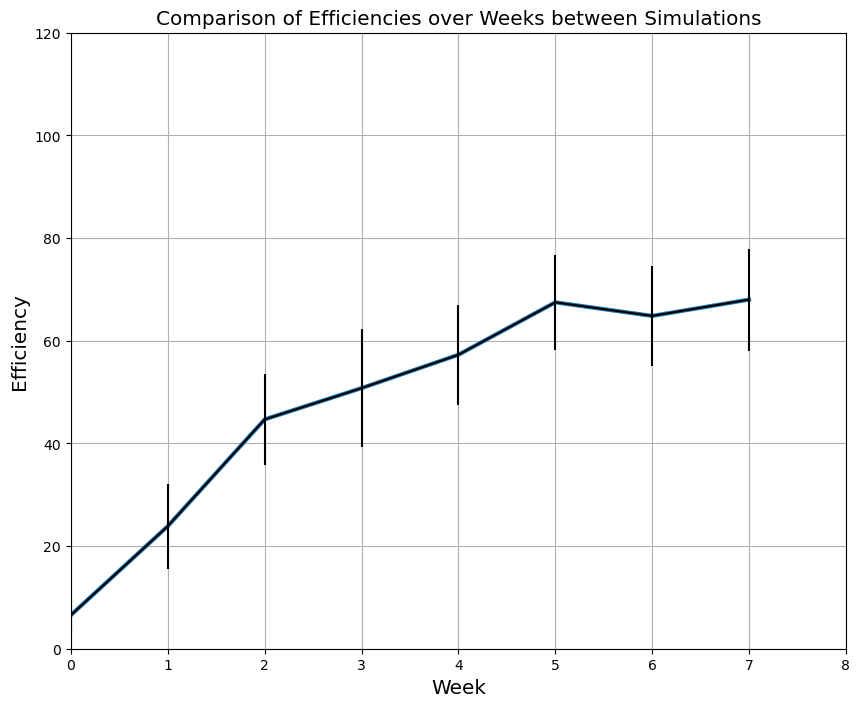

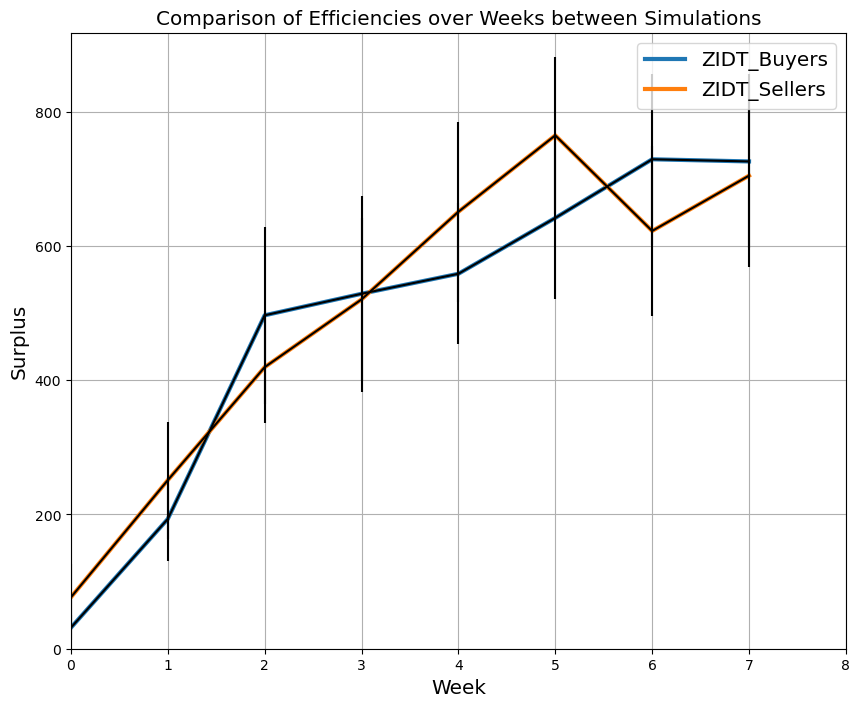

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


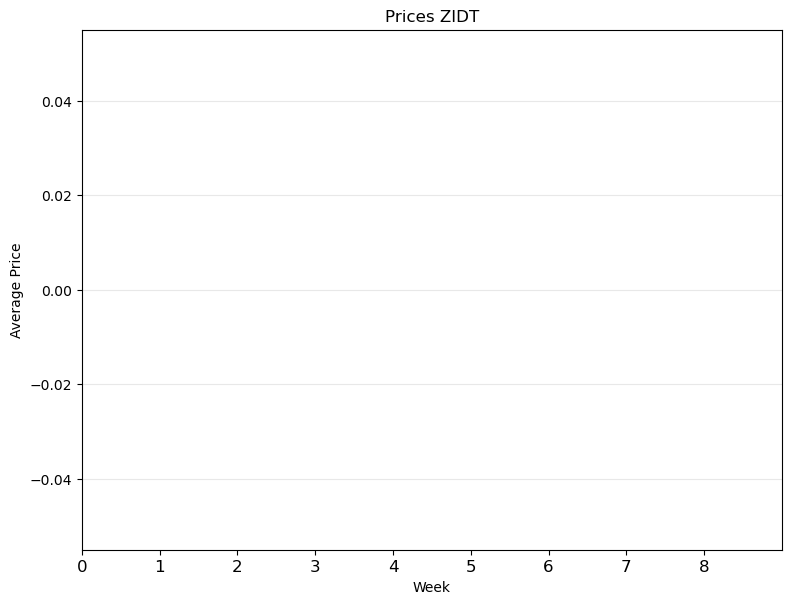

<Figure size 640x480 with 0 Axes>

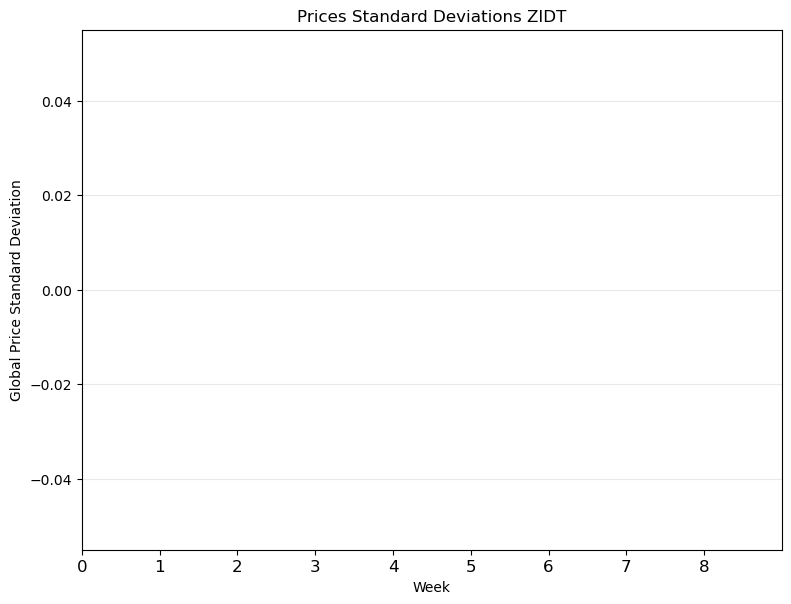

<Figure size 640x480 with 0 Axes>

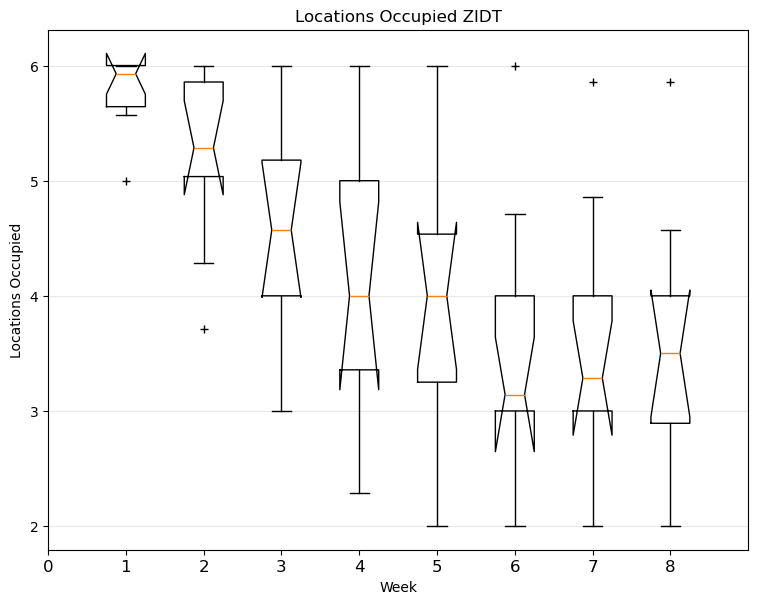

<Figure size 640x480 with 0 Axes>

In [ ]:
agZIDT_names = ['ZIDT_Buyers', 'ZIDT_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIDT'
strategy_params = None # Using default params
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIDT_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zidt_df, zidt_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=agZIDT_groups,
                group_names=agZIDT_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=True, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zidt_eff, zidt_class, zidt_group = dm_utils.summary_surplus(zidt_df)

dm_utils.graph_summary(zidt_eff, by=None)
dm_utils.graph_summary(zidt_group, by='agent_group')

zidt_al_df = dm_res_helpers.add_all_metrics(zidt_df, zidt_per_df)

"""
pr_zim = nb_helpers.format_df_for_boxplot(zidt_al_df, 'week', 'week_price_avg')
xlm = (0, 9)
xtc = np.arange(0, xlm[1], 1)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Prices ZIDT',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

pr_std_zim = nb_helpers.format_df_for_boxplot(zidt_al_df, 'week', 'week_price_std')
xlm = (0, 9)
xtc = np.arange(0, xlm[1], 1)
nb_helpers.plot_boxplot_data(pr_std_zim,
                             title='Prices Standard Deviations ZIDT',
                             y_lab='Global Price Standard Deviation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

loc_zim = nb_helpers.format_df_for_boxplot(zidt_al_df, 'week', 'week_loc_occupied')
xlm = (0, 9)
xtc = np.arange(0, xlm[1], 1)
nb_helpers.plot_boxplot_data(loc_zim,
                             title='Locations Occupied ZIDT',
                             y_lab='Locations Occupied',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()"""

# Single Location - Price Search Only

Running a MonteCarlo with parameters:
{'sim_name': 'ZIM_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZIM', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZIM', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['ZIM_Buyers', 'ZIM_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': 0}


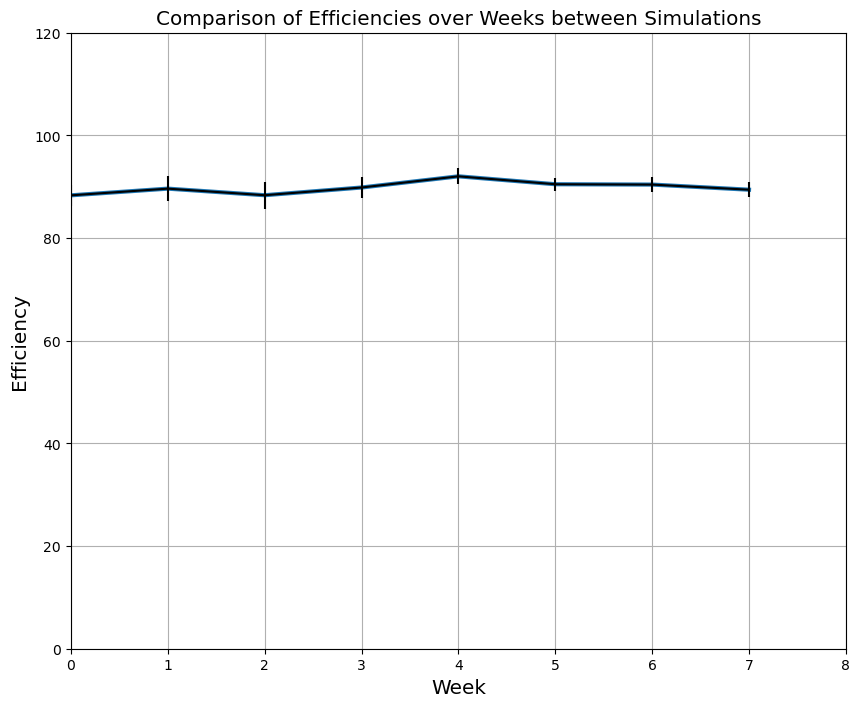

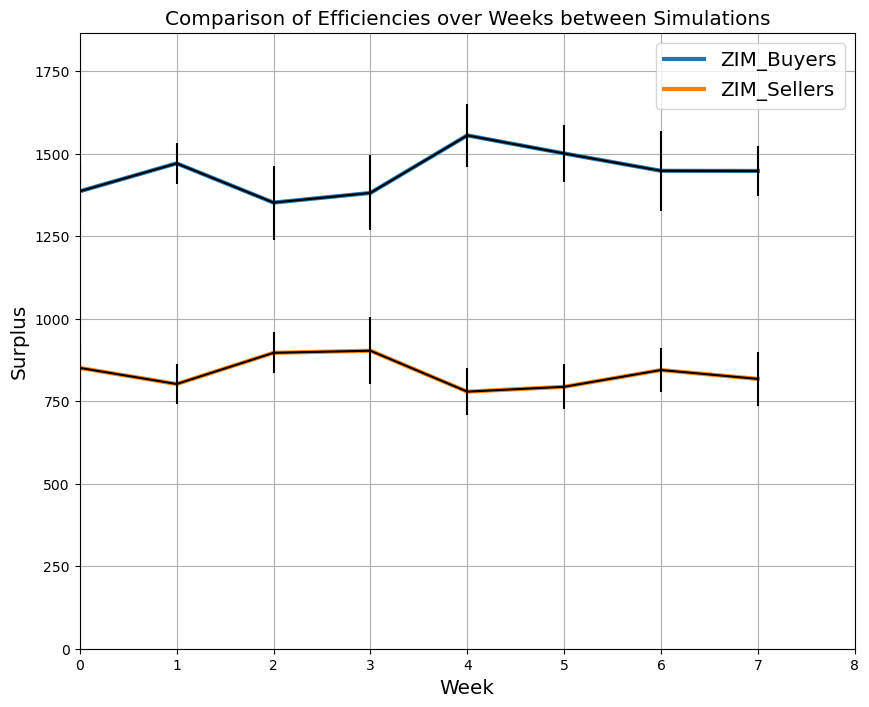

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


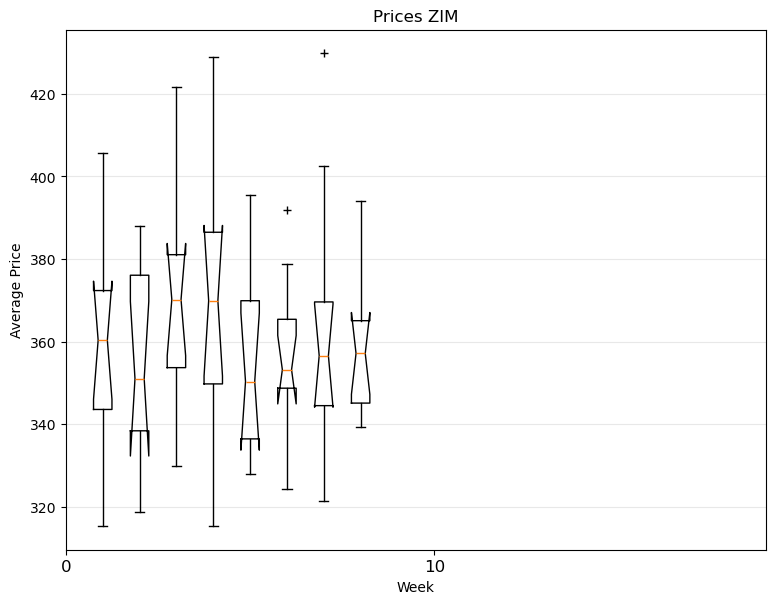

<Figure size 640x480 with 0 Axes>

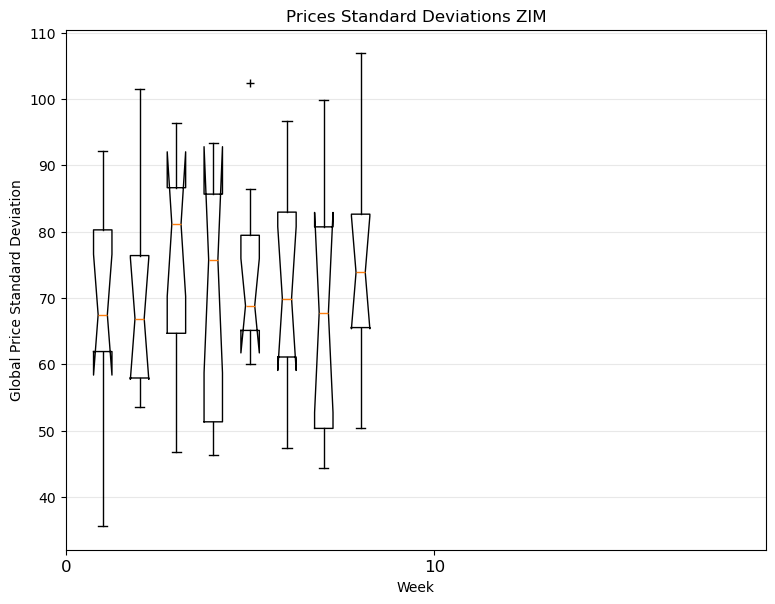

<Figure size 640x480 with 0 Axes>

In [2]:
agZIM_names = ['ZIM_Buyers', 'ZIM_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIM'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIM_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

zim_al_df = dm_res_helpers.add_all_metrics(zim_df, zim_per_df)

pr_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_avg')
pr_std_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_std')

xlm = (0, 19)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Prices ZIM',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

xlm = (0, 19)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_std_zim,
                             title='Prices Standard Deviations ZIM',
                             y_lab='Global Price Standard Deviation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

Running a MonteCarlo with parameters:
{'sim_name': 'ZIM_test', 'num_trials': 10, 'num_weeks': 20, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZIM', None, 200, 600, 5, 500, None, 0, None], [3, 'SELLER', 'ZIM', None, 200, 600, 5, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['ZIM_Buyers', 'ZIM_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': True, 'bargain_history_locations': False, 'bargain_history_duration': 0}


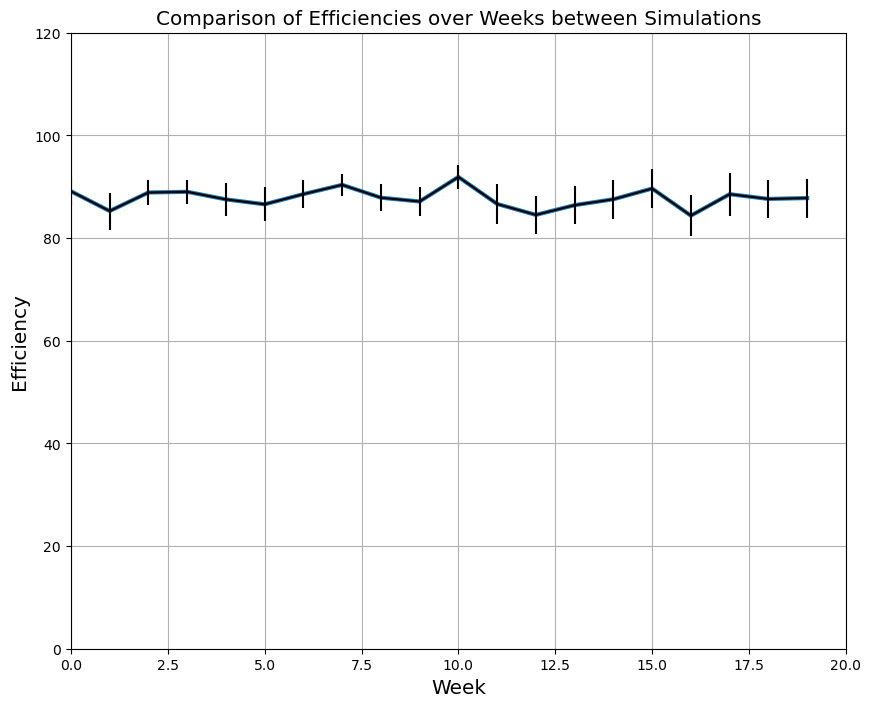

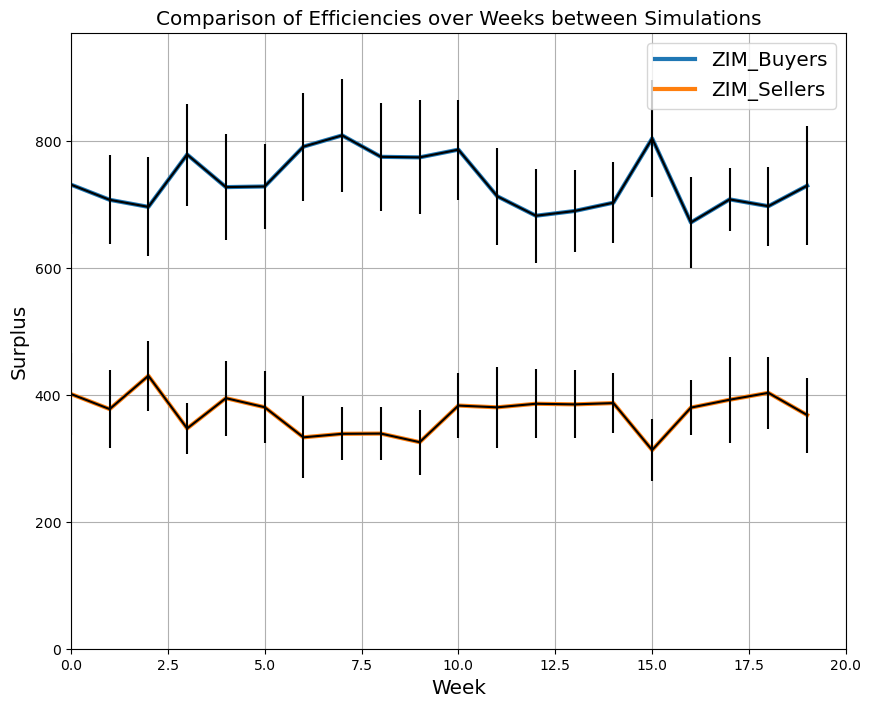

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


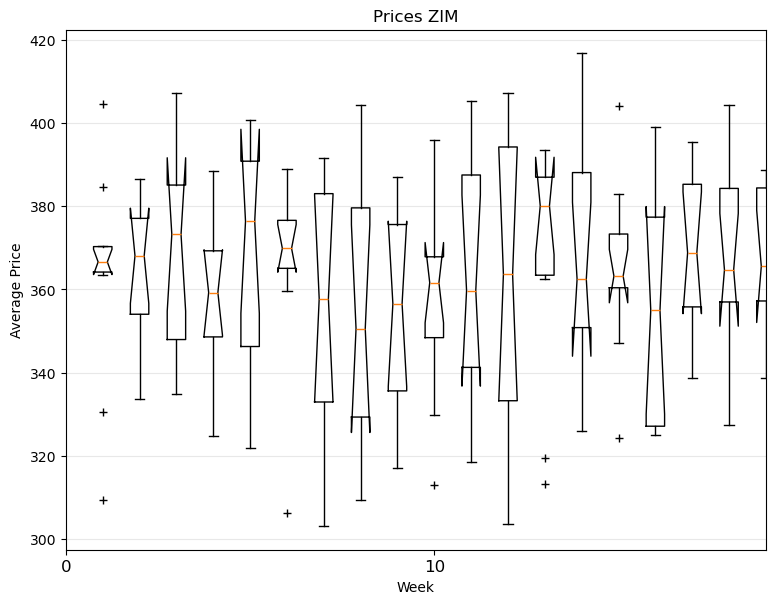

<Figure size 640x480 with 0 Axes>

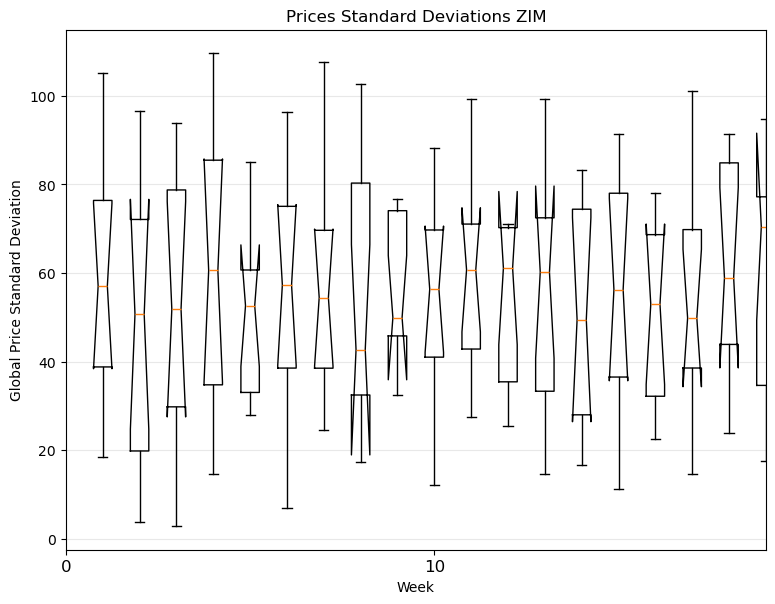

<Figure size 640x480 with 0 Axes>

In [ ]:
agZIM_names = ['ZIM_Buyers', 'ZIM_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIM'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIM_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=True, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

zim_al_df = dm_res_helpers.add_all_metrics(zim_df, zim_per_df)

pr_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_avg')
pr_std_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_std')

xlm = (0, 19)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Prices ZIM',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

xlm = (0, 19)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_std_zim,
                             title='Prices Standard Deviations ZIM',
                             y_lab='Global Price Standard Deviation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

# GLOBAL TESTS

In [ ]:
agZIM_names = ['ZIM_Buyers', 'ZIM_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIM'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIM_test',
                                             num_trials=10,
                num_weeks=50, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=4, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=True, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

zim_al_df = dm_res_helpers.add_all_metrics(zim_df, zim_per_df)

pr_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_avg')
pr_std_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_std')

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Prices ZIM',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_std_zim,
                             title='Prices Standard Deviations ZIM',
                             y_lab='Global Price Standard Deviation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()



Running a MonteCarlo with parameters:
{'sim_name': 'ZIM_test', 'num_trials': 10, 'num_weeks': 50, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 10, 'agent_groups': [[5, 'BUYER', 'ZIM', None, 200, 600, 5, 500, None, 0, None], [5, 'SELLER', 'ZIM', None, 200, 600, 5, 0, None, 0, None]], 'grid_size': 4, 'group_names': ['ZIM_Buyers', 'ZIM_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': True, 'bargain_history_locations': False, 'bargain_history_duration': 0}


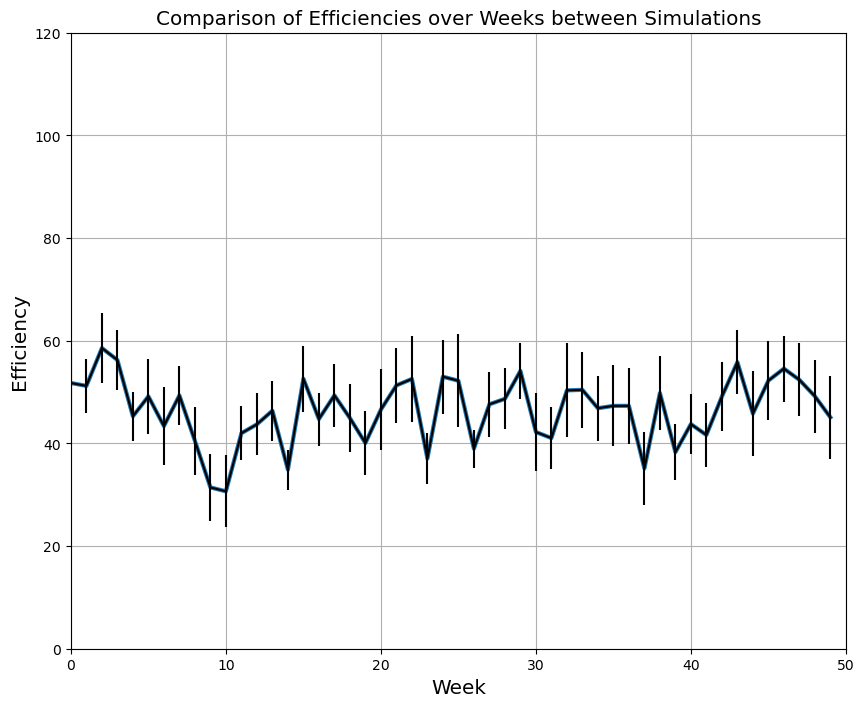

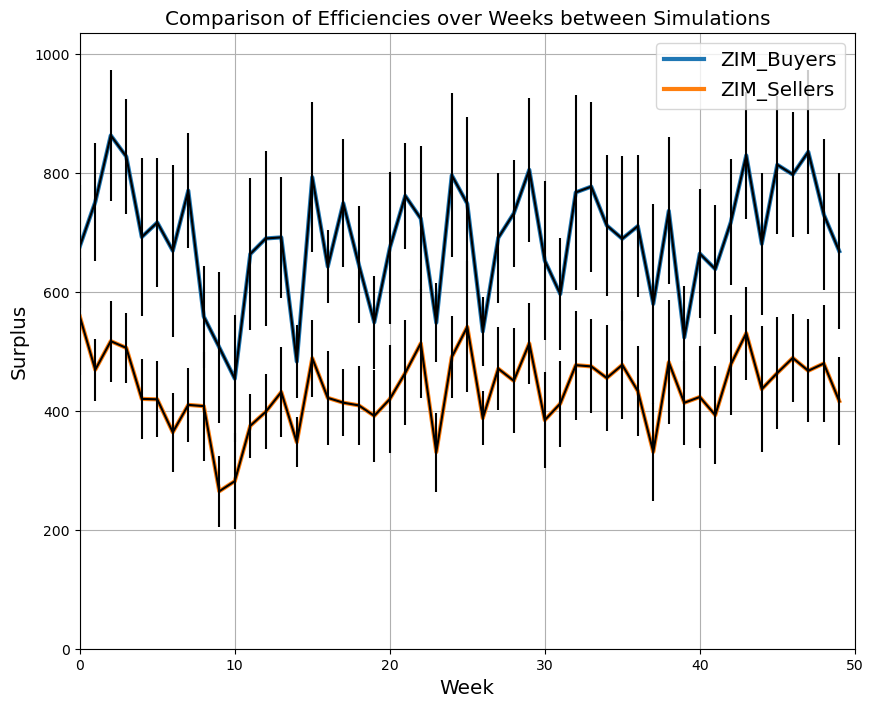

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


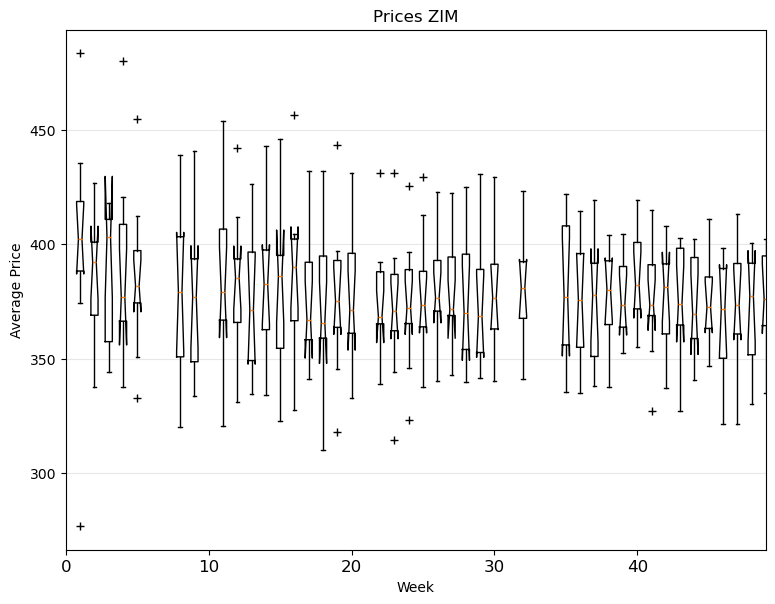

<Figure size 640x480 with 0 Axes>

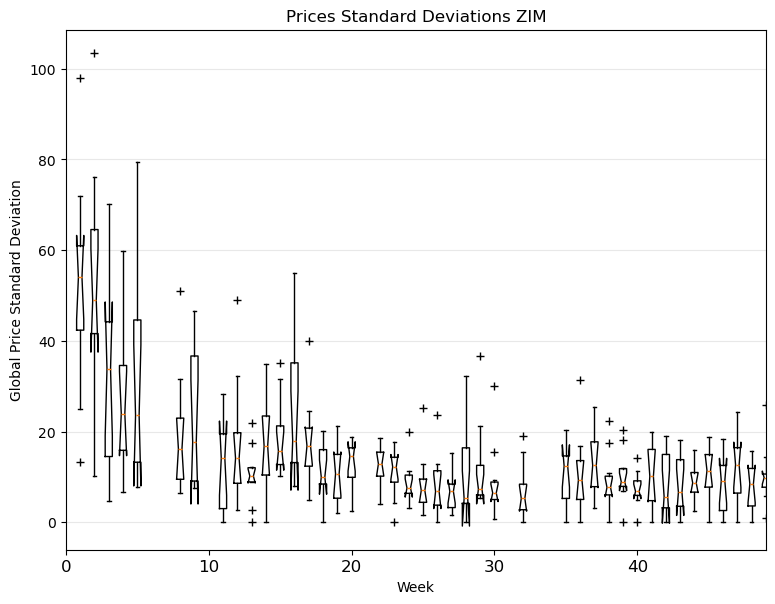

<Figure size 640x480 with 0 Axes>

# ZIMA TEST

## ZIMA Local

Running a MonteCarlo with parameters:
{'sim_name': 'ZIMA_test', 'num_trials': 10, 'num_weeks': 50, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 10, 'agent_groups': [[5, 'BUYER', 'ZIMA', None, 200, 600, 5, 500, None, 0, None], [5, 'SELLER', 'ZIMA', None, 200, 600, 5, 0, None, 0, None]], 'grid_size': 10, 'group_names': ['ZIMA_Buyers', 'ZIMA_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': 0}


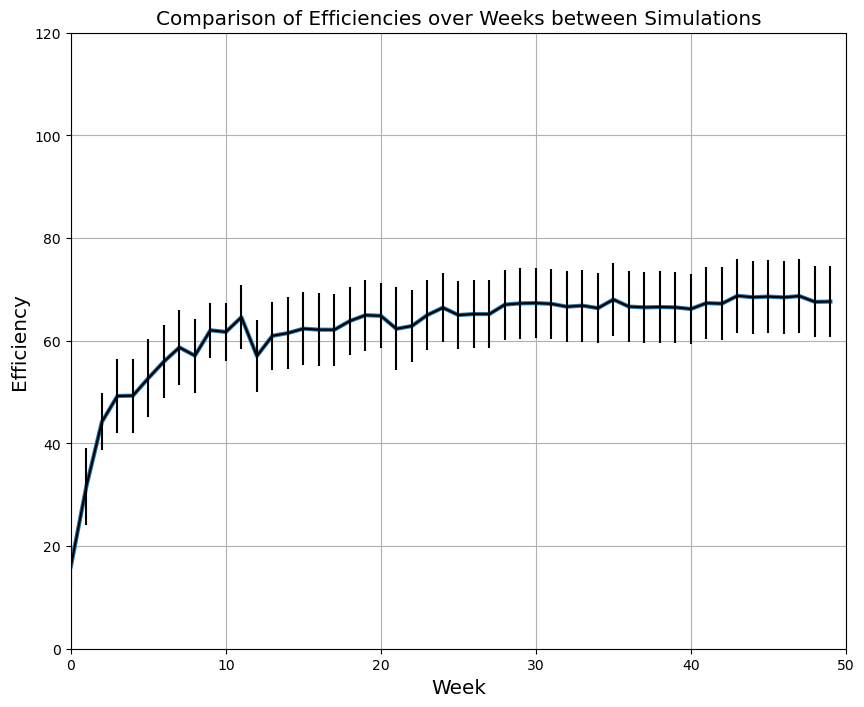

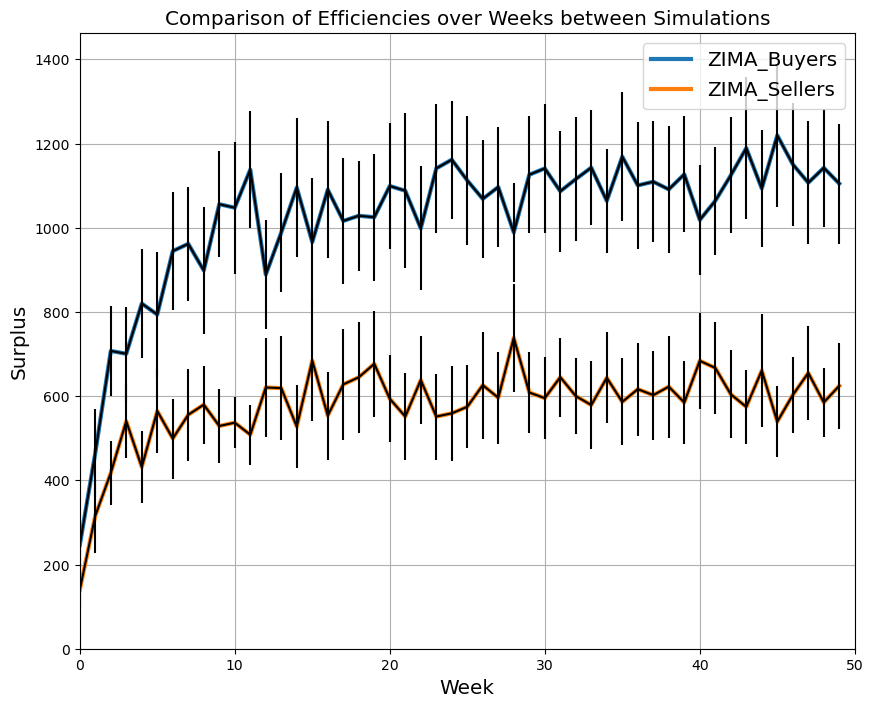

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


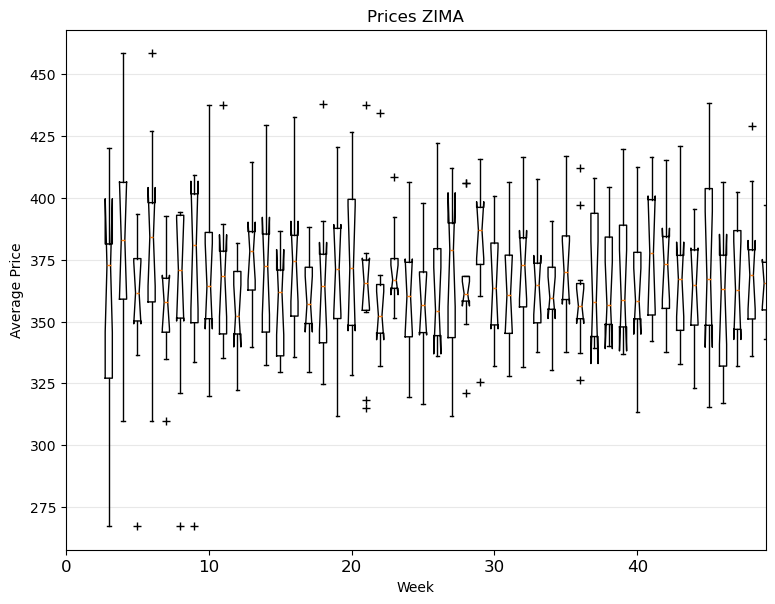

<Figure size 640x480 with 0 Axes>

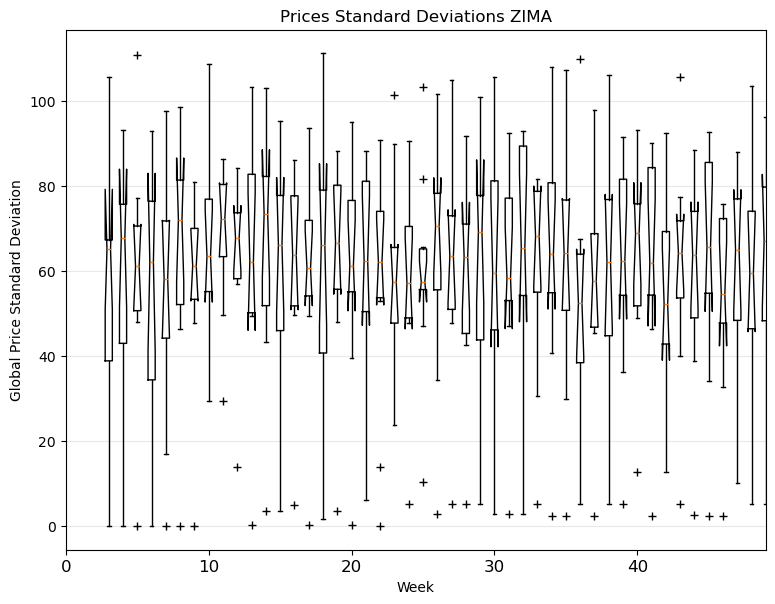

<Figure size 640x480 with 0 Axes>

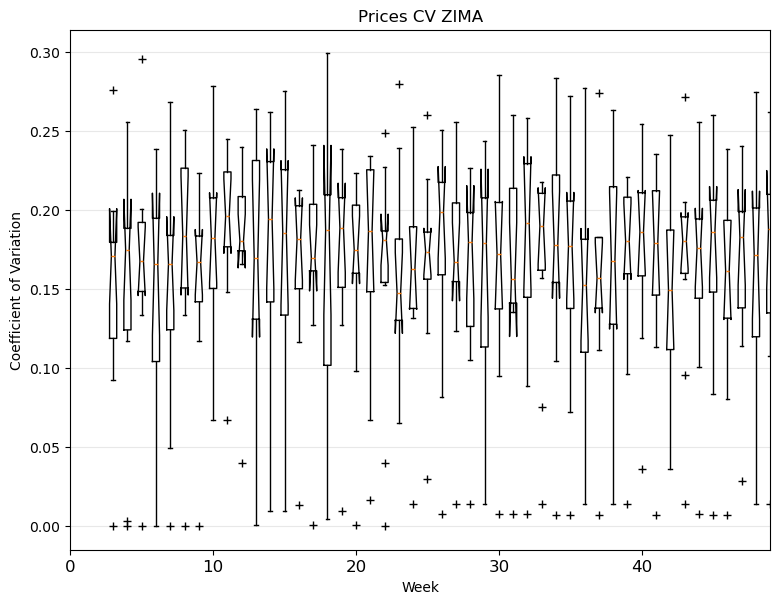

<Figure size 640x480 with 0 Axes>

In [ ]:
agZIM_names = ['ZIMA_Buyers', 'ZIMA_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIMA'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIMA_test',
                                             num_trials=10,
                num_weeks=50, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=10, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

zim_al_df = dm_res_helpers.add_all_metrics(zim_df, zim_per_df)

pr_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_avg')
xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Prices ZIMA',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

pr_std_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_std')
xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_std_zim,
                             title='Prices Standard Deviations ZIMA',
                             y_lab='Global Price Standard Deviation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

pr_cv_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_cv')
xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_cv_zim,
                             title='Prices CV ZIMA',
                             y_lab='Coefficient of Variation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

loc_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_loc_occupied')
xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(loc_zim,
                             title='Locations Occupied ZIMA',
                             y_lab='Locations Occupied',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

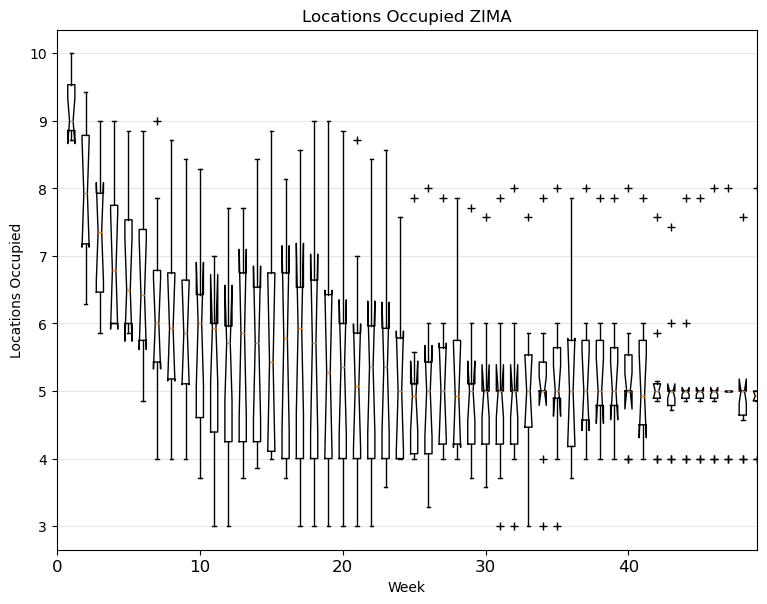

<Figure size 640x480 with 0 Axes>

## ZIMA Global Info

Running a MonteCarlo with parameters:
{'sim_name': 'ZIMA_test', 'num_trials': 10, 'num_weeks': 50, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 10, 'agent_groups': [[5, 'BUYER', 'ZIMA', None, 200, 600, 5, 500, None, 0, None], [5, 'SELLER', 'ZIMA', None, 200, 600, 5, 0, None, 0, None]], 'grid_size': 10, 'group_names': ['ZIMA_Buyers', 'ZIMA_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': True, 'bargain_history_locations': False, 'bargain_history_duration': 0}


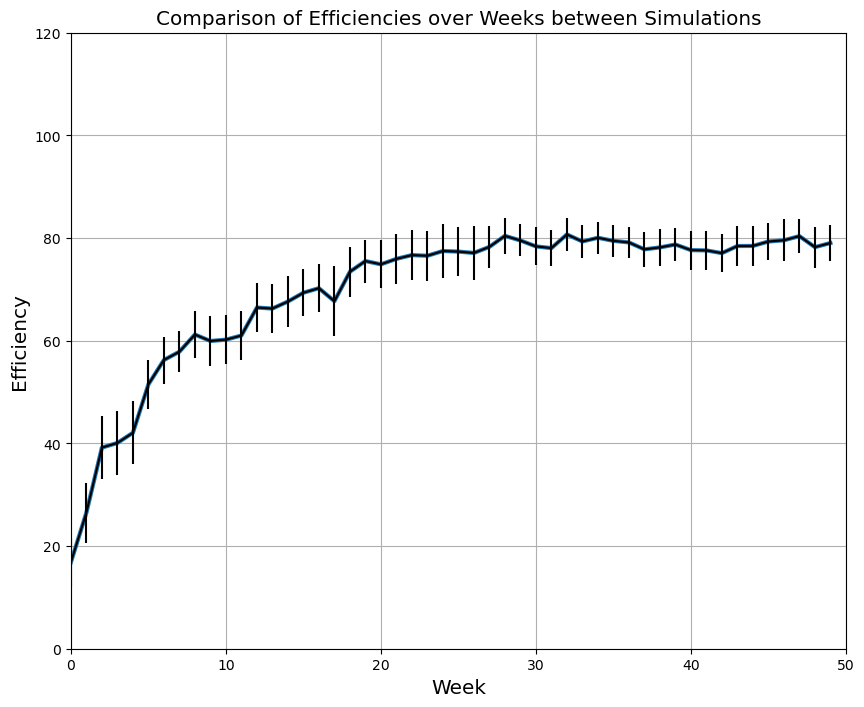

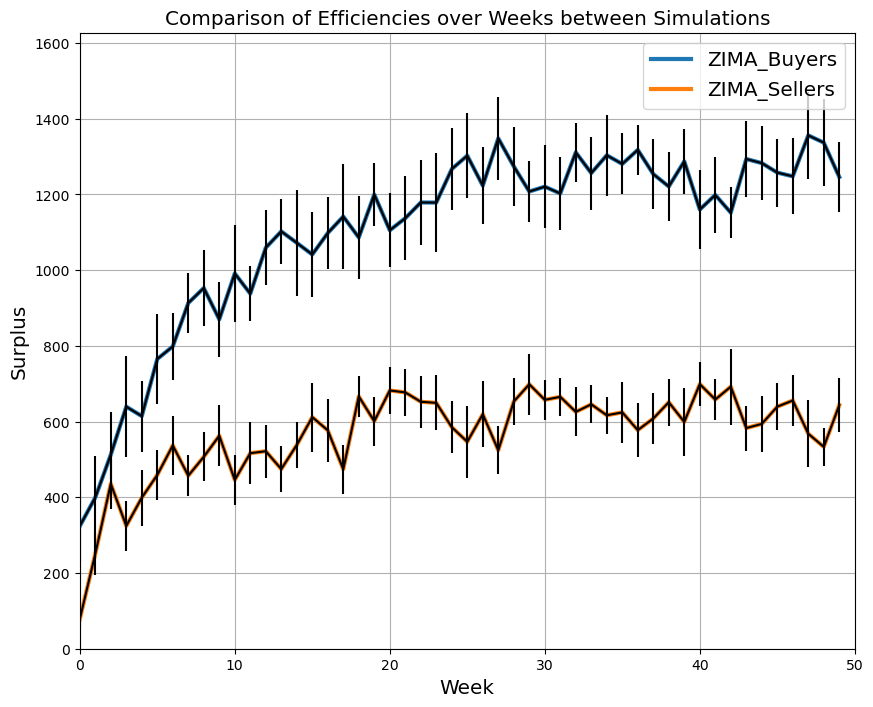

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


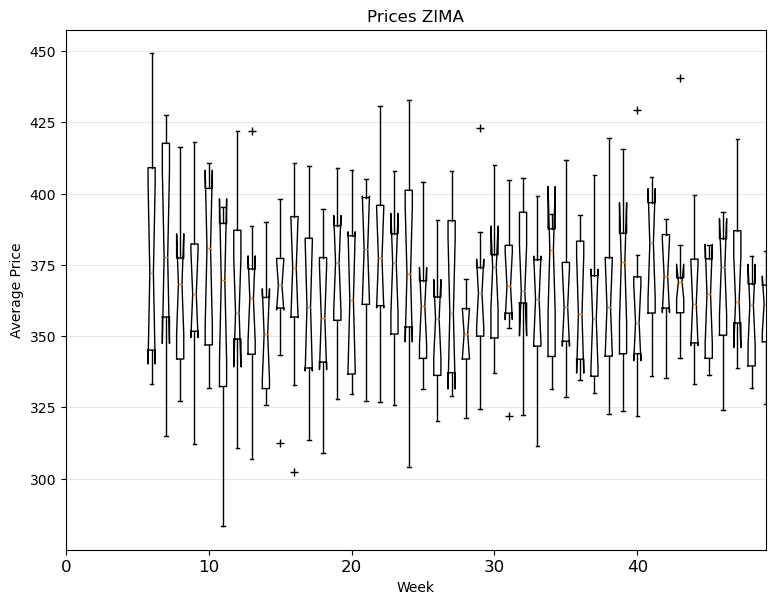

<Figure size 640x480 with 0 Axes>

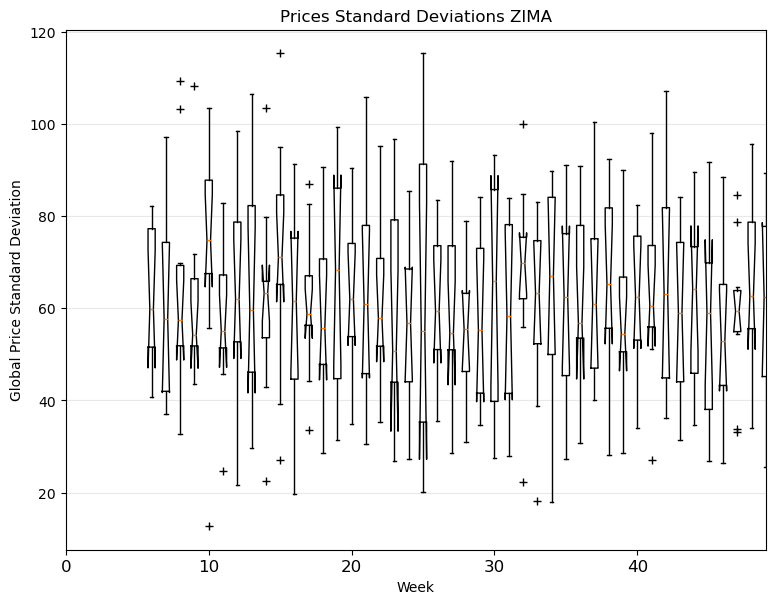

<Figure size 640x480 with 0 Axes>

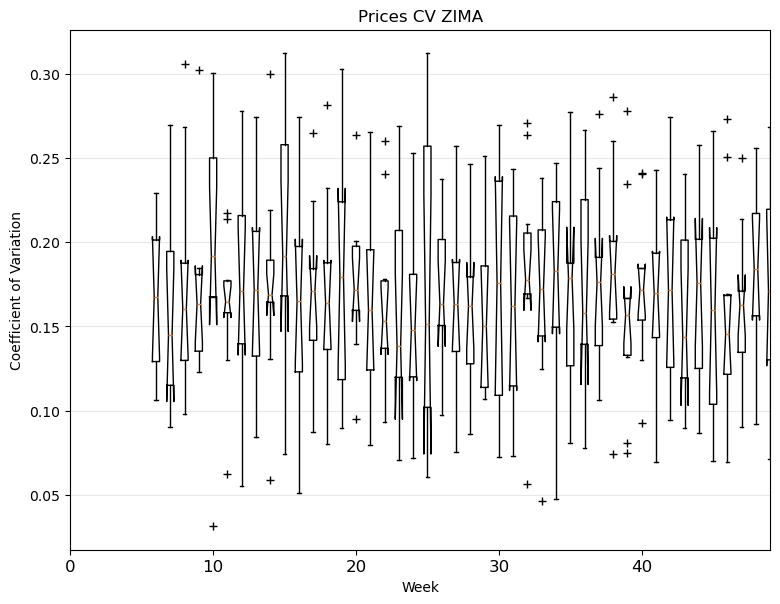

<Figure size 640x480 with 0 Axes>

In [ ]:
agZIM_names = ['ZIMA_Buyers', 'ZIMA_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIMA'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIMA_test',
                                             num_trials=10,
                num_weeks=50, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=10, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=True, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

zim_al_df = dm_res_helpers.add_all_metrics(zim_df, zim_per_df)

pr_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_avg')
pr_std_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_std')

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Prices ZIMA',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_std_zim,
                             title='Prices Standard Deviations ZIMA',
                             y_lab='Global Price Standard Deviation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

pr_cv_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_cv')

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_cv_zim,
                             title='Prices CV ZIMA',
                             y_lab='Coefficient of Variation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

loc_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_loc_occupied')
xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(loc_zim,
                             title='Locations Occupied ZIMA',
                             y_lab='Locations Occupied',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

In [4]:
pr_w_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_loc_price_avg')
pr_w_std_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_loc_price_std')

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Location Prices ZIMA',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Location Price STD ZIMA',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price STD',
                             xlim=xlm, n=1, colors='red')
plt.show()


NameError: name 'zim_al_df' is not defined

In [ ]:
agZIM_names = ['ZIMA_Buyers', 'ZIMA_Sellers']
ag_n = 5; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIMA'
strategy_params = None #ZID does not take strategy parameters
ag_lb = 200; ag_ub = 600; ag_nu = 5; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
agZIM_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim_df, zim_per_df = dm_sim.make_monte_carlo(sim_name='ZIMA_test',
                                             num_trials=10,
                num_weeks=10, 
                num_periods=7,
                num_rounds=5, 
                num_traders=10,
                agent_groups=agZIM_groups,
                group_names=agZIM_names,
                grid_size=4, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=True, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim_eff, zim_class, zim_group = dm_utils.summary_surplus(zim_df)

dm_utils.graph_summary(zim_eff, by=None)
dm_utils.graph_summary(zim_group, by='agent_group')

zim_al_df = dm_res_helpers.add_all_metrics(zim_df, zim_per_df)

pr_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_avg')
pr_std_zim = nb_helpers.format_df_for_boxplot(zim_al_df, 'week', 'week_price_std')

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_zim,
                             title='Prices ZIMA',
                             y_lab='Average Price',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

xlm = (0, 49)
xtc = np.arange(0, xlm[1], 10)
nb_helpers.plot_boxplot_data(pr_std_zim,
                             title='Prices Standard Deviations ZIMA',
                             y_lab='Global Price Standard Deviation',
                             x_lab='Week',
                             x_ticks=xtc, rbars=None, savename=None,
                             legend=False, labels='Price',
                             xlim=xlm, n=1, colors='red')
plt.show()

ZIDA Baseline

ZIMA Baseline

# SPACE SEARCH ONLY

In [ ]:
# ZID Search
ag_names = ['ZID0_Buyers', 'ZID0_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZID'
strategy_params = None # Using default params
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zid0_df, zid0_per_df = dm_sim.make_monte_carlo(sim_name='ZID0_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zid0_al_df = dm_res_helpers.add_all_metrics(zid0_df, zid0_per_df)

# ZIDA Search
ag_names = ['ZIDA_Buyers', 'ZIDA_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIDA'
strategy_params = None # Using default params
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zida_df, zida_per_df = dm_sim.make_monte_carlo(sim_name='ZIDA_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zida_al_df = dm_res_helpers.add_all_metrics(zida_df, zida_per_df)


# ZIDT Search
ag_names = ['ZIDT_Buyers', 'ZIDT_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIDT'
strategy_params = None # Using default params
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zidt_df, zidt_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zidt_al_df = dm_res_helpers.add_all_metrics(zidt_df, zidt_per_df)

Running a MonteCarlo with parameters:
{'sim_name': 'ZID0_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZID', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZID', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 6, 'group_names': ['ZID0_Buyers', 'ZID0_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIDA_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZIDA', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZIDA', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 6, 'group_names': ['ZIDA_Buyers', 'ZIDA_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIDT_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZIDT', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZIDT', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 6, 'group_names': ['ZIDT_Buyers', 'ZIDT_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


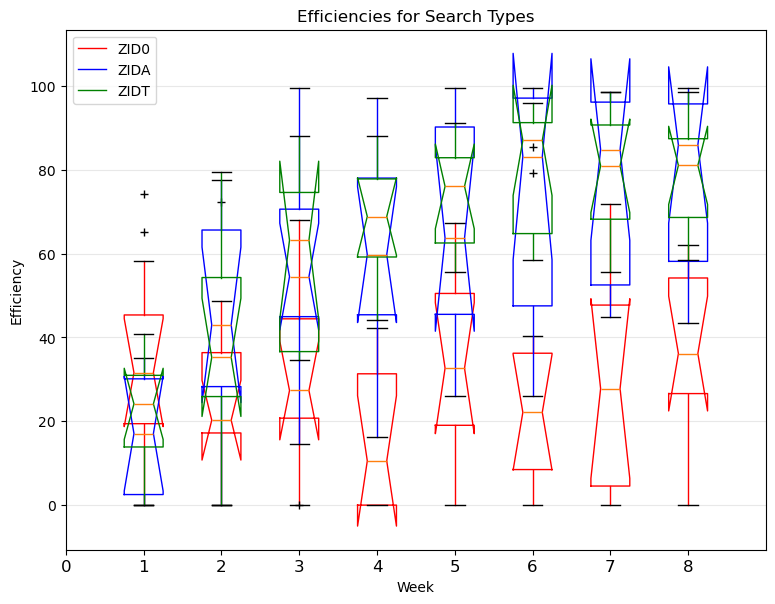

<Figure size 640x480 with 0 Axes>

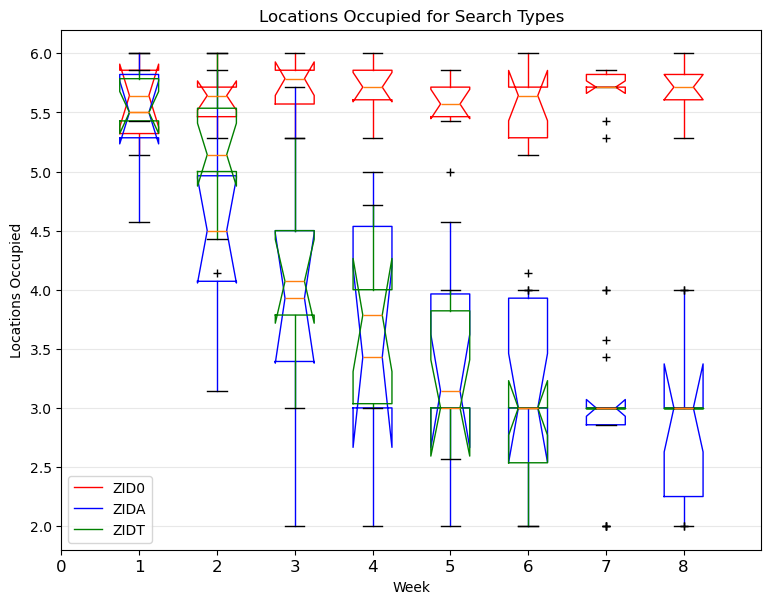

<Figure size 640x480 with 0 Axes>

In [7]:
# Comparison of efficiencies
zid0_eff = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_eff')
zida_eff = nb_helpers.format_df_for_boxplot(zida_al_df, 'week', 'week_eff')
zidt_eff = nb_helpers.format_df_for_boxplot(zidt_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [zid0_eff, zida_eff, zidt_eff]
ttl = "Efficiencies for Search Types"
labs = ["ZID0", "ZIDA", "ZIDT"]
ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)

nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])

# Comparison of locations occupied
zid0_loc = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_loc_occupied')
zida_loc = nb_helpers.format_df_for_boxplot(zida_al_df, 'week', 'week_loc_occupied')
zidt_loc = nb_helpers.format_df_for_boxplot(zidt_al_df, 'week', 'week_loc_occupied')

box_dt = [zid0_loc, zida_loc, zidt_loc]
ttl = "Locations Occupied for Search Types"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])




# PRICE SEARCH ONLY

In [ ]:
# ZID Search
ag_names = ['ZID0_Buyers', 'ZID0_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZID'
strategy_params = None # Using default params
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zid0_df, zid0_per_df = dm_sim.make_monte_carlo(sim_name='ZID0_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zid0_al_df = dm_res_helpers.add_all_metrics(zid0_df, zid0_per_df)

# ZIDP Search
ag_names = ['ZIP0_Buyers', 'ZIP0_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIDP'
strategy_params = None # Using default params
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zidp_df, zidp_per_df = dm_sim.make_monte_carlo(sim_name='ZIP0_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zidp_al_df = dm_res_helpers.add_all_metrics(zidp_df, zidp_per_df)


# ZIM0 Search
ag_names = ['ZIM0_Buyers', 'ZIM0_Sellers']
ag_n = 3; ag_types = ['BUYER', 'SELLER']; ag_class = 'ZIM'
strategy_params = None # Using default params
ag_lb = 200; ag_ub = 600; ag_nu = 8; ag_end = [500, 0]; ag_pf = None
ag_me = 0; ag_loc = None
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim0_df, zim0_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim0_al_df = dm_res_helpers.add_all_metrics(zim0_df, zim0_per_df)

Running a MonteCarlo with parameters:
{'sim_name': 'ZID0_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZID', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZID', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['ZID0_Buyers', 'ZID0_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIP0_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZIDP', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZIDP', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['ZIP0_Buyers', 'ZIP0_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIDT_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[3, 'BUYER', 'ZIM', None, 200, 600, 8, 500, None, 0, None], [3, 'SELLER', 'ZIM', None, 200, 600, 8, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['ZIM0_Buyers', 'ZIM0_Sellers'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': 0}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


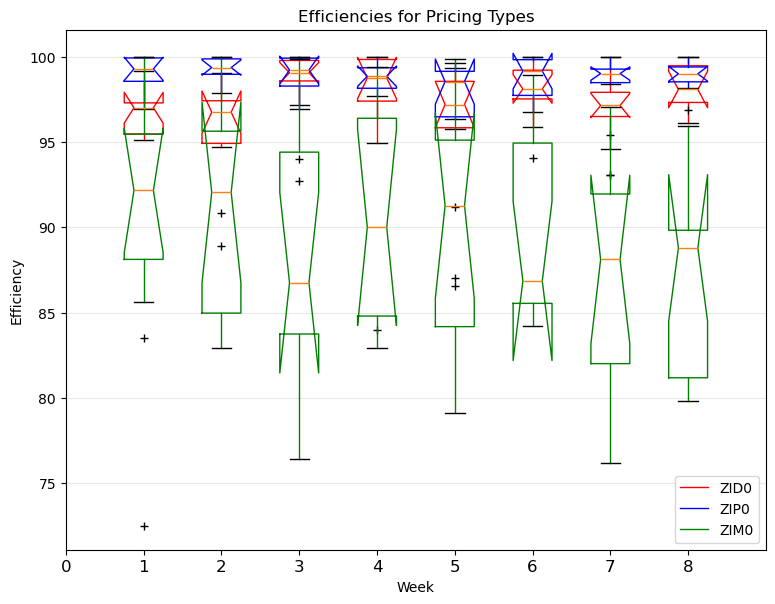

<Figure size 640x480 with 0 Axes>

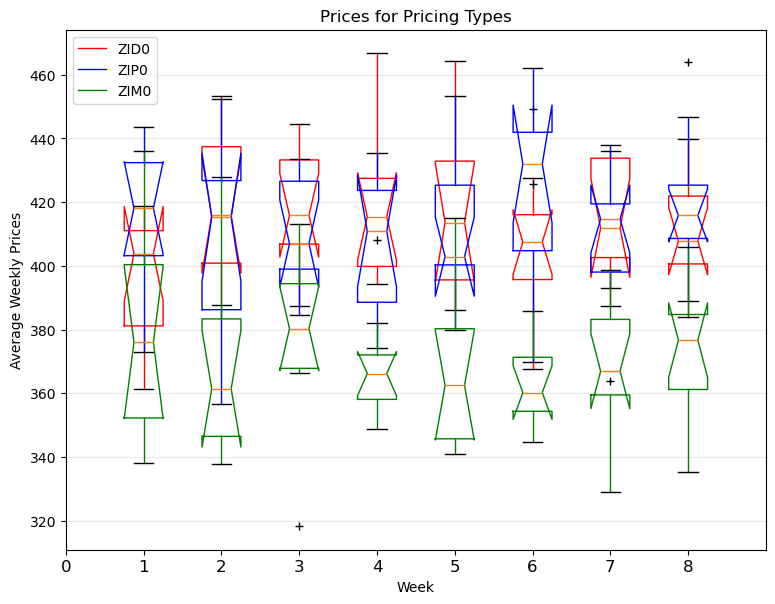

<Figure size 640x480 with 0 Axes>

In [16]:
# Comparison of efficiencies
zid0_eff = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_eff')
zip0_eff = nb_helpers.format_df_for_boxplot(zidp_al_df, 'week', 'week_eff')
zim0_eff = nb_helpers.format_df_for_boxplot(zim0_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [zid0_eff, zip0_eff, zim0_eff]
ttl = "Efficiencies for Pricing Types"
labs = ["ZID0", "ZIP0", "ZIM0"]
ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)

nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])

# Comparison of locations occupied
zid0_prc = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_price_avg')
zip0_prc = nb_helpers.format_df_for_boxplot(zidp_al_df, 'week', 'week_price_avg')
zim0_prc = nb_helpers.format_df_for_boxplot(zim0_al_df, 'week', 'week_price_avg')

box_dt = [zid0_prc, zip0_prc, zim0_prc]
ttl = "Prices for Pricing Types"
ylab = "Average Weekly Prices"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])


# LOCATION SEARCH - SECTION LINES

In [2]:
# Base Inputs
ag_names = ['Buyer_1', 'Buyer_2', 'Buyer_3', 
            'Seller_1', 'Seller_2', 'Seller_3']
ag_n = 1; ag_types = ['BUYER']*3+['SELLER']*3
ag_lb = [200, 300, 400, 200, 300, 400]; 
ag_ub = [600, 700, 800, 600, 700, 800];
ag_nu = 8; 
ag_end = [500]*3+[0]*3; ag_pf = None
ag_me = 0; ag_loc = None

## Gen Baselines

Running a MonteCarlo with parameters:
{'sim_name': 'ZID0_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[1, 'BUYER', 'ZID', None, 200, 600, 8, 500, None, 0, None], [1, 'BUYER', 'ZID', None, 300, 700, 8, 500, None, 0, None], [1, 'BUYER', 'ZID', None, 400, 800, 8, 500, None, 0, None], [1, 'SELLER', 'ZID', None, 200, 600, 8, 0, None, 0, None], [1, 'SELLER', 'ZID', None, 300, 700, 8, 0, None, 0, None], [1, 'SELLER', 'ZID', None, 400, 800, 8, 0, None, 0, None]], 'grid_size': 6, 'group_names': ['Buyer_1', 'Buyer_2', 'Buyer_3', 'Seller_1', 'Seller_2', 'Seller_3'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIDA_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[1, 'BUYER', 'ZIDA', None, 200, 600, 8, 500, None, 0, None], [1, 'BUYER', 'ZIDA', None, 300, 700, 8, 500, None, 0, None], [1, 'BUYER', 'ZIDA', None, 400, 800, 8, 500, None, 0, None], [1, 'SELLER', 'ZIDA', None, 200, 600, 8, 0, None, 0, None], [1, 'SELLER', 'ZIDA', None, 300, 700, 8, 0, None, 0, None], [1, 'SELLER', 'ZIDA', None, 400, 800, 8, 0, None, 0, None]], 'grid_size': 6, 'group_names': ['Buyer_1', 'Buyer_2', 'Buyer_3', 'Seller_1', 'Seller_2', 'Seller_3'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIDT_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[1, 'BUYER', 'ZIDT', None, 200, 600, 8, 500, None, 0, None], [1, 'BUYER', 'ZIDT', None, 300, 700, 8, 500, None, 0, None], [1, 'BUYER', 'ZIDT', None, 400, 800, 8, 500, None, 0, None], [1, 'SELLER', 'ZIDT', None, 200, 600, 8, 0, None, 0, None], [1, 'SELLER', 'ZIDT', None, 300, 700, 8, 0, None, 0, None], [1, 'SELLER', 'ZIDT', None, 400, 800, 8, 0, None, 0, None]], 'grid_size': 6, 'group_names': ['Buyer_1', 'Buyer_2', 'Buyer_3', 'Seller_1', 'Seller_2', 'Seller_3'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


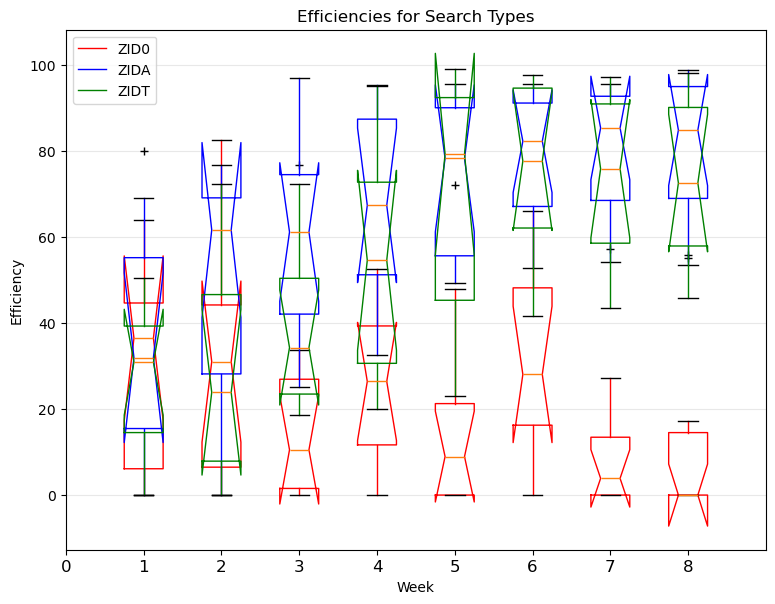

<Figure size 640x480 with 0 Axes>

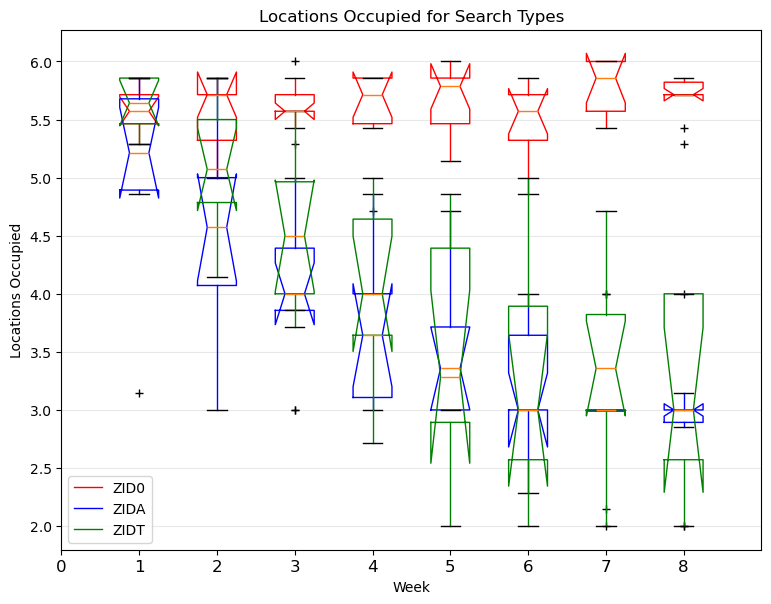

<Figure size 640x480 with 0 Axes>

In [ ]:


# ZID0 Search
ag_class = 'ZID'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zid0_df, zid0_per_df = dm_sim.make_monte_carlo(sim_name='ZID0_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zid0_al_df = dm_res_helpers.add_all_metrics(zid0_df, zid0_per_df)

# ZIDA Search
ag_class = 'ZIDA'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zida_df, zida_per_df = dm_sim.make_monte_carlo(sim_name='ZIDA_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zida_al_df = dm_res_helpers.add_all_metrics(zida_df, zida_per_df)


# ZIDT Search
ag_class = 'ZIDT'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zidt_df, zidt_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zidt_al_df = dm_res_helpers.add_all_metrics(zidt_df, zidt_per_df)

# Comparison of efficiencies
zid0_eff = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_eff')
zida_eff = nb_helpers.format_df_for_boxplot(zida_al_df, 'week', 'week_eff')
zidt_eff = nb_helpers.format_df_for_boxplot(zidt_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [zid0_eff, zida_eff, zidt_eff]
ttl = "Efficiencies for Search Types"
labs = ["ZID0", "ZIDA", "ZIDT"]
ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)

nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])

# Comparison of locations occupied
zid0_loc = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_loc_occupied')
zida_loc = nb_helpers.format_df_for_boxplot(zida_al_df, 'week', 'week_loc_occupied')
zidt_loc = nb_helpers.format_df_for_boxplot(zidt_al_df, 'week', 'week_loc_occupied')

box_dt = [zid0_loc, zida_loc, zidt_loc]
ttl = "Locations Occupied for Search Types"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])




Running a MonteCarlo with parameters:
{'sim_name': 'ZID0_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[1, 'BUYER', 'ZID', None, 200, 600, 8, 500, None, 0, None], [1, 'BUYER', 'ZID', None, 300, 700, 8, 500, None, 0, None], [1, 'BUYER', 'ZID', None, 400, 800, 8, 500, None, 0, None], [1, 'SELLER', 'ZID', None, 200, 600, 8, 0, None, 0, None], [1, 'SELLER', 'ZID', None, 300, 700, 8, 0, None, 0, None], [1, 'SELLER', 'ZID', None, 400, 800, 8, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['Buyer_1', 'Buyer_2', 'Buyer_3', 'Seller_1', 'Seller_2', 'Seller_3'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIP0_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[1, 'BUYER', 'ZIDP', None, 200, 600, 8, 500, None, 0, None], [1, 'BUYER', 'ZIDP', None, 300, 700, 8, 500, None, 0, None], [1, 'BUYER', 'ZIDP', None, 400, 800, 8, 500, None, 0, None], [1, 'SELLER', 'ZIDP', None, 200, 600, 8, 0, None, 0, None], [1, 'SELLER', 'ZIDP', None, 300, 700, 8, 0, None, 0, None], [1, 'SELLER', 'ZIDP', None, 400, 800, 8, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['Buyer_1', 'Buyer_2', 'Buyer_3', 'Seller_1', 'Seller_2', 'Seller_3'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': -1}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Running a MonteCarlo with parameters:
{'sim_name': 'ZIDT_test', 'num_trials': 10, 'num_weeks': 8, 'num_periods': 7, 'num_rounds': 5, 'num_traders': 6, 'agent_groups': [[1, 'BUYER', 'ZIM', None, 200, 600, 8, 500, None, 0, None], [1, 'BUYER', 'ZIM', None, 300, 700, 8, 500, None, 0, None], [1, 'BUYER', 'ZIM', None, 400, 800, 8, 500, None, 0, None], [1, 'SELLER', 'ZIM', None, 200, 600, 8, 0, None, 0, None], [1, 'SELLER', 'ZIM', None, 300, 700, 8, 0, None, 0, None], [1, 'SELLER', 'ZIM', None, 400, 800, 8, 0, None, 0, None]], 'grid_size': 1, 'group_names': ['Buyer_1', 'Buyer_2', 'Buyer_3', 'Seller_1', 'Seller_2', 'Seller_3'], 'bargain_round_broadcasts': False, 'bargain_history_global': False, 'bargain_history_locations': False, 'bargain_history_duration': 0}


/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


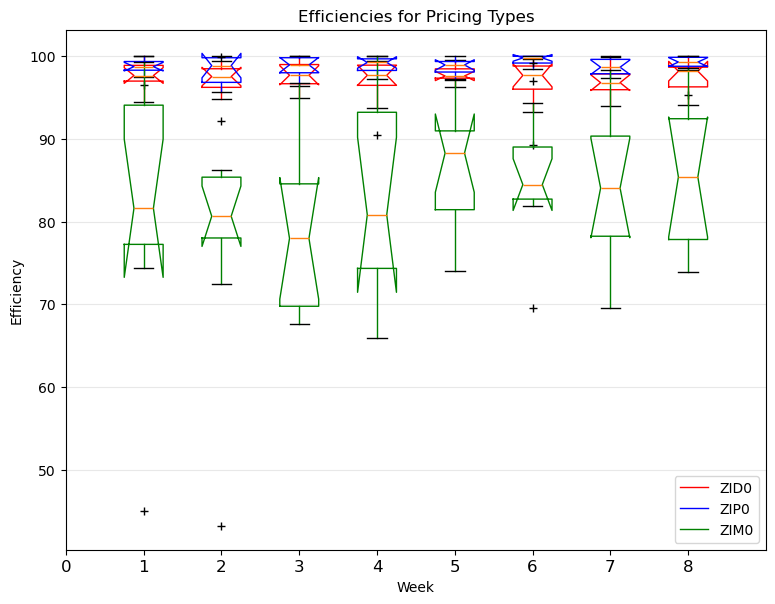

<Figure size 640x480 with 0 Axes>

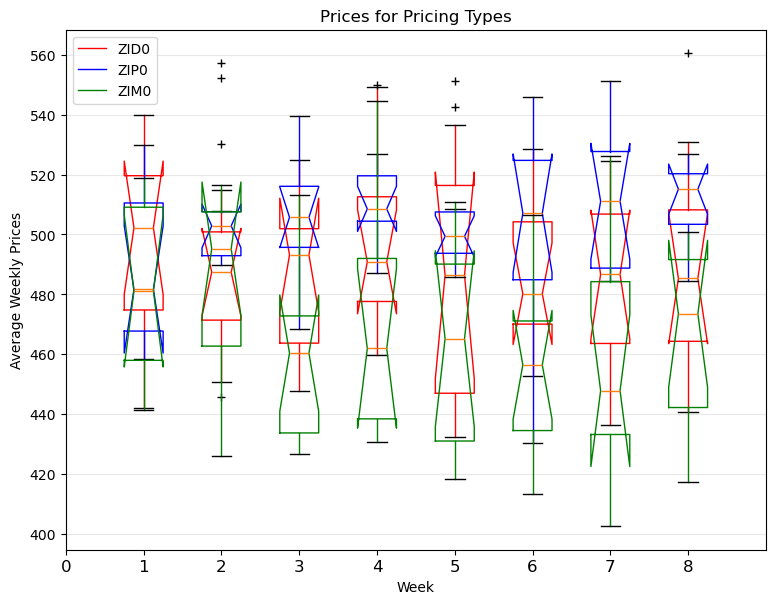

<Figure size 640x480 with 0 Axes>

In [19]:
# ZID Search
ag_class = 'ZID'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zid0_df, zid0_per_df = dm_sim.make_monte_carlo(sim_name='ZID0_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zid0_al_df = dm_res_helpers.add_all_metrics(zid0_df, zid0_per_df)

# ZIDP Search
ag_class = 'ZIDP'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zidp_df, zidp_per_df = dm_sim.make_monte_carlo(sim_name='ZIP0_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=True)

zidp_al_df = dm_res_helpers.add_all_metrics(zidp_df, zidp_per_df)


# ZIM0 Search
ag_class = 'ZIM'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zim0_df, zim0_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=1, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=True)

zim0_al_df = dm_res_helpers.add_all_metrics(zim0_df, zim0_per_df)

# Comparison of efficiencies
zid0_eff = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_eff')
zip0_eff = nb_helpers.format_df_for_boxplot(zidp_al_df, 'week', 'week_eff')
zim0_eff = nb_helpers.format_df_for_boxplot(zim0_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [zid0_eff, zip0_eff, zim0_eff]
ttl = "Efficiencies for Pricing Types"
labs = ["ZID0", "ZIP0", "ZIM0"]
ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)

nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])

# Comparison of locations occupied
zid0_prc = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_price_avg')
zip0_prc = nb_helpers.format_df_for_boxplot(zidp_al_df, 'week', 'week_price_avg')
zim0_prc = nb_helpers.format_df_for_boxplot(zim0_al_df, 'week', 'week_price_avg')

box_dt = [zid0_prc, zip0_prc, zim0_prc]
ttl = "Prices for Pricing Types"
ylab = "Average Weekly Prices"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=3,
                             colors=['red', 'blue', 'green'])


# Combining Pricing and Search Models

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

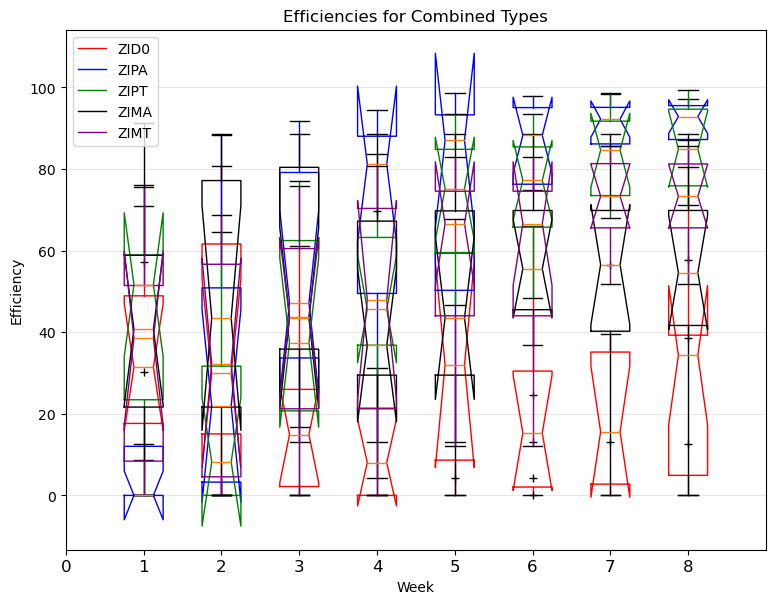

<Figure size 640x480 with 0 Axes>

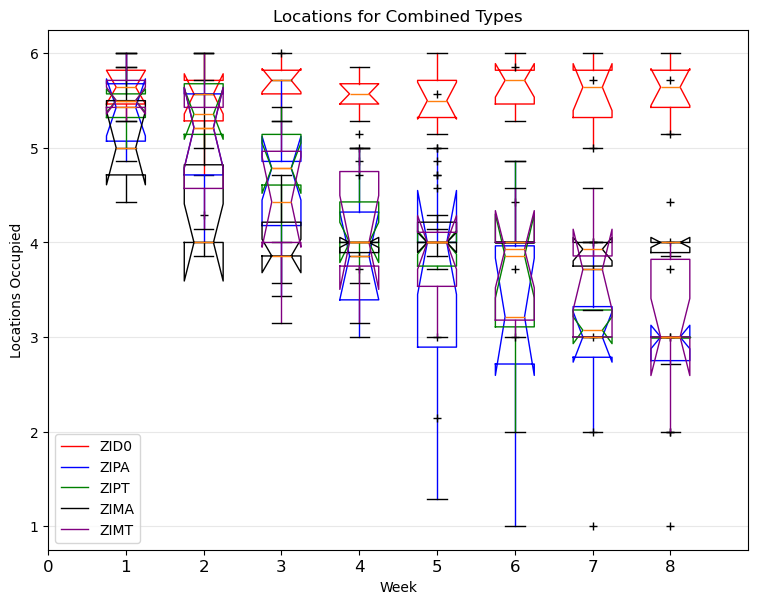

<Figure size 640x480 with 0 Axes>

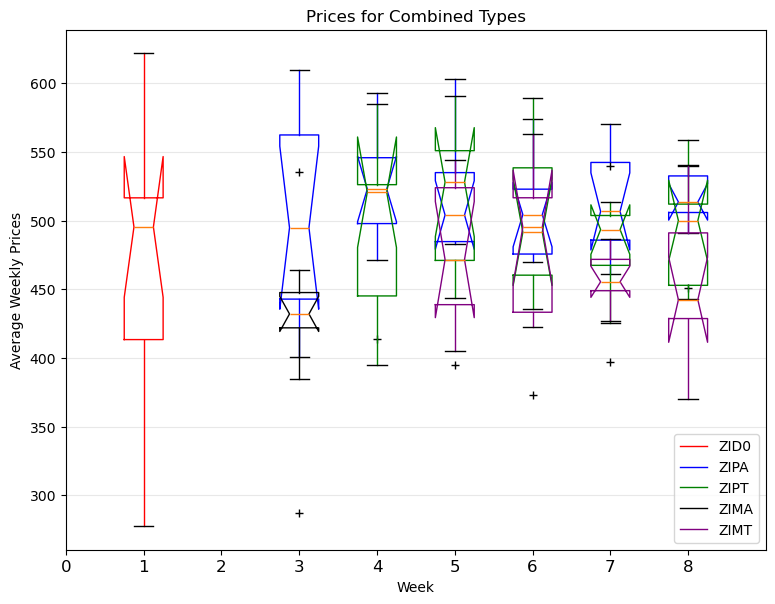

<Figure size 640x480 with 0 Axes>

In [3]:
# ZID Search
ag_class = 'ZID'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zid0_df, zid0_per_df = dm_sim.make_monte_carlo(sim_name='null',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=False)

zid0_al_df = dm_res_helpers.add_all_metrics(zid0_df, zid0_per_df)

# ZIDP Search
ag_class = 'ZIDPA'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zipa_df, zipa_per_df = dm_sim.make_monte_carlo(sim_name='null',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=False)

zipa_al_df = dm_res_helpers.add_all_metrics(zipa_df, zipa_per_df)

# ZIPT
ag_class = 'ZIPT'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zipt_df, zipt_per_df = dm_sim.make_monte_carlo(sim_name='null',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=False)

zipt_al_df = dm_res_helpers.add_all_metrics(zipt_df, zipt_per_df)

# ZIMA Search
ag_class = 'ZIMA'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zima_df, zima_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zima_al_df = dm_res_helpers.add_all_metrics(zima_df, zima_per_df)

# ZIMT Search
ag_class = 'ZIMT'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zimt_df, zimt_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zimt_al_df = dm_res_helpers.add_all_metrics(zimt_df, zimt_per_df)

# Comparison of efficiencies
zid0_eff = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_eff')
zipa_eff = nb_helpers.format_df_for_boxplot(zipa_al_df, 'week', 'week_eff')
zipt_eff = nb_helpers.format_df_for_boxplot(zipt_al_df, 'week', 'week_eff')
zima_eff = nb_helpers.format_df_for_boxplot(zima_al_df, 'week', 'week_eff')
zimt_eff = nb_helpers.format_df_for_boxplot(zimt_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [zid0_eff, zipa_eff, zipt_eff, zima_eff, zimt_eff]
ttl = "Efficiencies for Combined Types"
labs = ["ZID0", "ZIPA", "ZIPT", "ZIMA", "ZIMT"]
ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue', 'green', 'black', 'purple']

nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
zid0_loc = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_loc_occupied')
zipa_loc = nb_helpers.format_df_for_boxplot(zipa_al_df, 'week', 'week_loc_occupied')
zipt_loc = nb_helpers.format_df_for_boxplot(zipt_al_df, 'week', 'week_loc_occupied')
zima_loc = nb_helpers.format_df_for_boxplot(zima_al_df, 'week', 'week_loc_occupied')
zimt_loc = nb_helpers.format_df_for_boxplot(zimt_al_df, 'week', 'week_loc_occupied')

box_dt = [zid0_loc, zipa_loc, zipt_loc, zima_loc, zimt_loc]
ttl = "Locations for Combined Types"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of prices
zid0_prc = nb_helpers.format_df_for_boxplot(zid0_al_df, 'week', 'week_price_avg')
zipa_prc = nb_helpers.format_df_for_boxplot(zipa_al_df, 'week', 'week_price_avg')
zipt_prc = nb_helpers.format_df_for_boxplot(zipt_al_df, 'week', 'week_price_avg')
zima_prc = nb_helpers.format_df_for_boxplot(zima_al_df, 'week', 'week_price_avg')
zimt_prc = nb_helpers.format_df_for_boxplot(zimt_al_df, 'week', 'week_price_avg')

box_dt = [zid0_prc, zipa_prc, zipt_prc, zima_prc, zimt_prc]
ttl = "Prices for Combined Types"
ylab = "Average Weekly Prices"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)


# TEST SUBSIDY

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

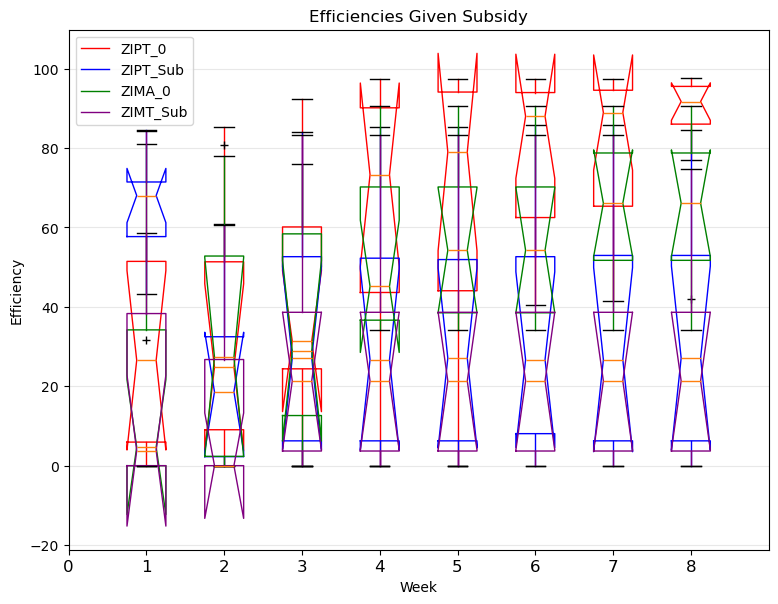

<Figure size 640x480 with 0 Axes>

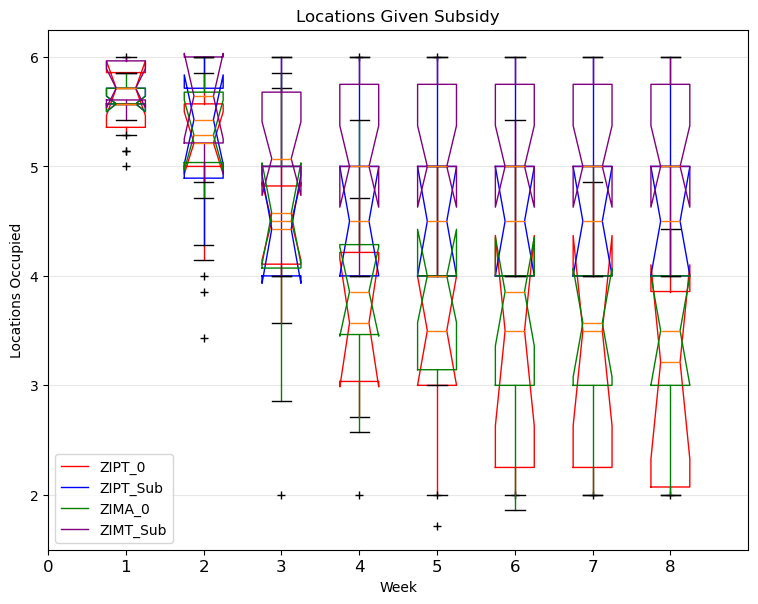

<Figure size 640x480 with 0 Axes>

In [5]:
# ZIPT
ag_class = 'ZIPT'
strategy_params = {'subsidy':0} # Using other default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zipt_0_df, zipt_0_per_df = dm_sim.make_monte_carlo(sim_name='sub1',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=False)

zipt_0_al_df = dm_res_helpers.add_all_metrics(zipt_0_df, zipt_0_per_df)

# ZIPT
ag_class = 'ZIPT'
strategy_params = {'subsidy':10} # Using other default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zipt_sub_df, zipt_sub_per_df = dm_sim.make_monte_carlo(sim_name='sub1',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=-1,
                
                return_df=True, return_period_df=True,
                print_params=False)

zipt_sub_df = dm_res_helpers.add_all_metrics(zipt_sub_df, zipt_sub_per_df)

# ZIMT Search
ag_class = 'ZIMT'
strategy_params = {'subsidy':0} # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zimt_0_df, zimt_0_per_df = dm_sim.make_monte_carlo(sim_name='sub2',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zimt_0_al_df = dm_res_helpers.add_all_metrics(zimt_0_df, zimt_0_per_df)

# ZIMT Search
ag_class = 'ZIMT'
strategy_params = {'subsidy':10} # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zimt_sub_df, zimt_sub_per_df = dm_sim.make_monte_carlo(sim_name='sub2',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zimt_sub_al_df = dm_res_helpers.add_all_metrics(zimt_sub_df, zimt_sub_per_df)

# Comparison of efficiencies
zipt_0_eff = nb_helpers.format_df_for_boxplot(zipt_0_al_df, 'week', 'week_eff')
zipt_sub_eff = nb_helpers.format_df_for_boxplot(zipt_sub_df, 'week', 'week_eff')
zimt_0_eff = nb_helpers.format_df_for_boxplot(zimt_0_al_df, 'week', 'week_eff')
zimt_sub_eff = nb_helpers.format_df_for_boxplot(zimt_sub_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [zipt_0_eff, zipt_sub_eff, zimt_0_eff, zimt_sub_eff]
ttl = "Efficiencies Given Subsidy"
labs = ["ZIPT_0", "ZIPT_Sub", "ZIMA_0", "ZIMT_Sub"]
ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue', 'green', 'purple']

nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
zipt_0_loc = nb_helpers.format_df_for_boxplot(zipt_0_al_df, 'week', 'week_loc_occupied')
zipt_sub_loc = nb_helpers.format_df_for_boxplot(zipt_sub_df, 'week', 'week_loc_occupied')
zimt_0_loc = nb_helpers.format_df_for_boxplot(zimt_0_al_df, 'week', 'week_loc_occupied')
zimt_sub_loc = nb_helpers.format_df_for_boxplot(zimt_sub_al_df, 'week', 'week_loc_occupied')

box_dt = [zipt_0_loc, zipt_sub_loc, zimt_0_loc, zimt_sub_loc]
ttl = "Locations Given Subsidy"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)


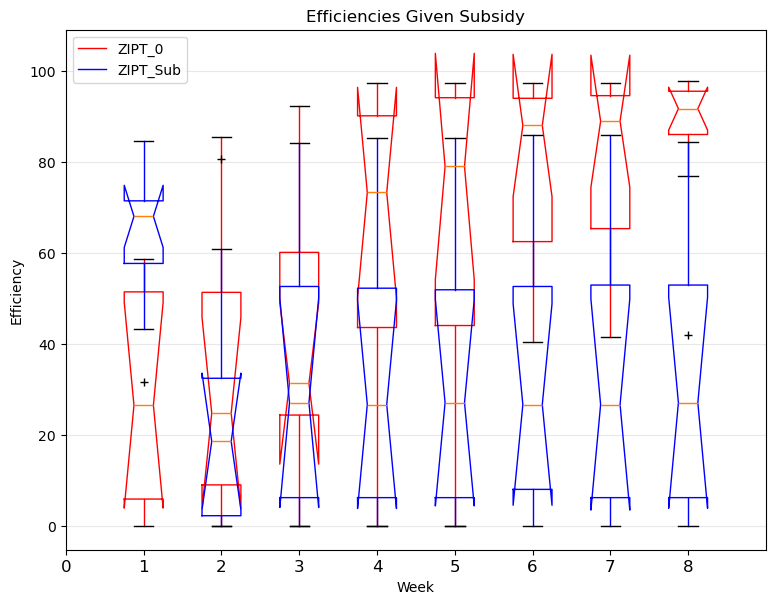

<Figure size 640x480 with 0 Axes>

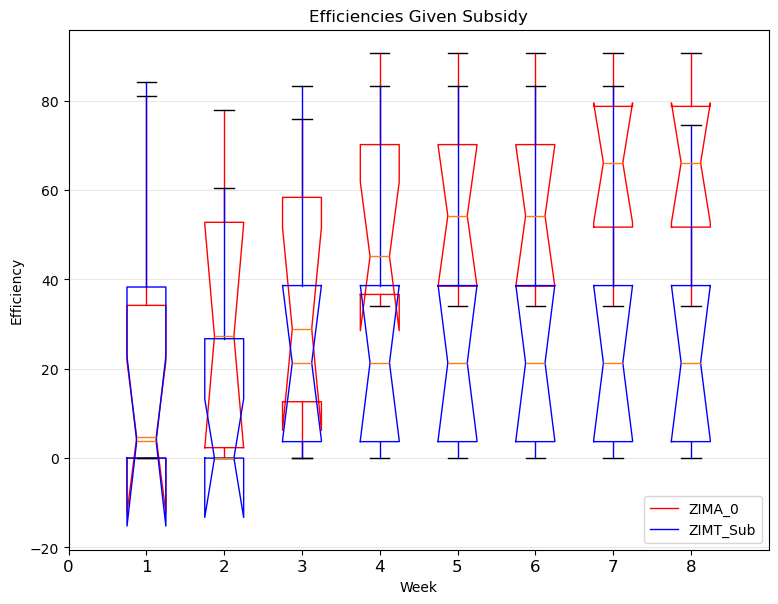

<Figure size 640x480 with 0 Axes>

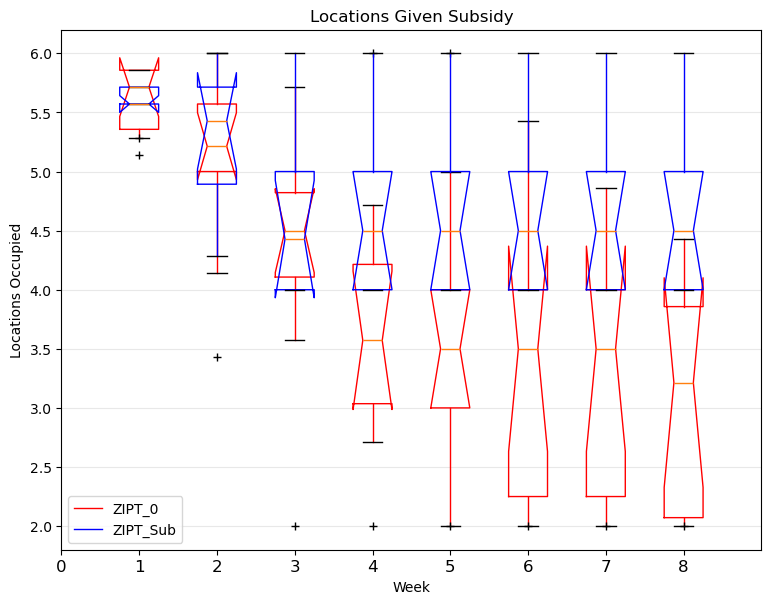

<Figure size 640x480 with 0 Axes>

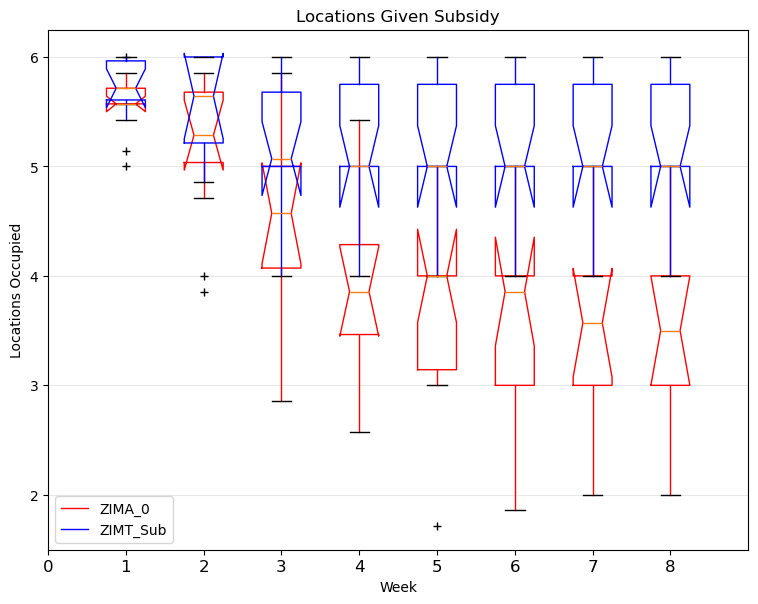

<Figure size 640x480 with 0 Axes>

In [7]:
# Plot the boxplot data
box_dt = [zipt_0_eff, zipt_sub_eff]
ttl = "Efficiencies Given Subsidy"
labs = ["ZIPT_0", "ZIPT_Sub"]
ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue']

nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

box_dt = [zimt_0_eff, zimt_sub_eff]
labs = ["ZIMA_0", "ZIMT_Sub"]
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
labs = ["ZIPT_0", "ZIPT_Sub"]
box_dt = [zipt_0_loc, zipt_sub_loc]
ttl = "Locations Given Subsidy"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

box_dt = [zimt_0_loc, zimt_sub_loc]
labs = ["ZIMA_0", "ZIMT_Sub"]
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)


# TEST INFO

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

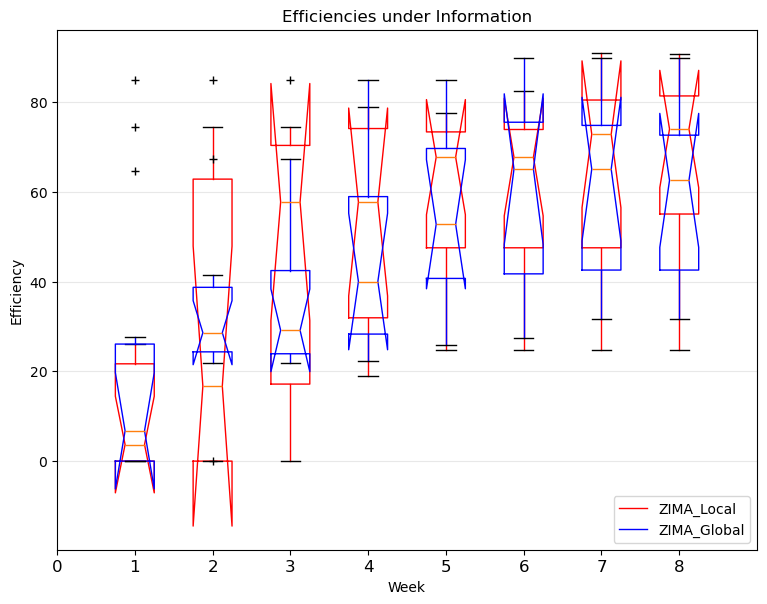

<Figure size 640x480 with 0 Axes>

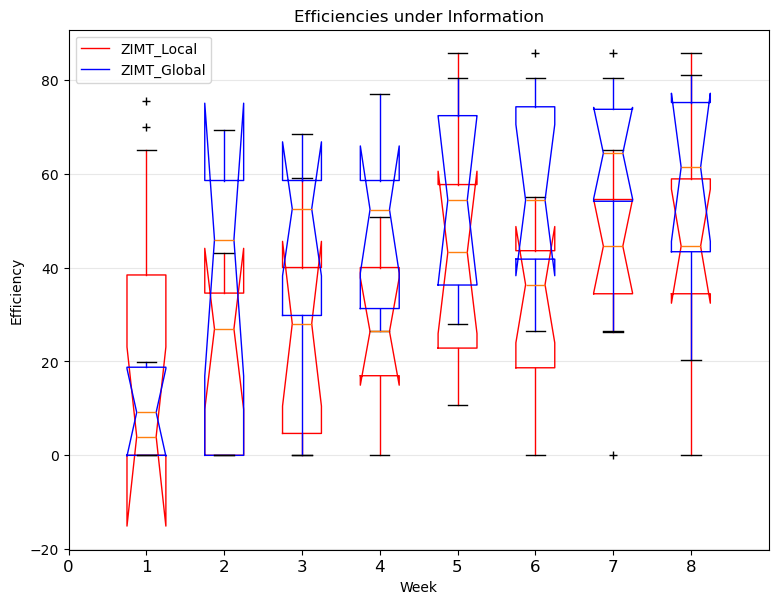

<Figure size 640x480 with 0 Axes>

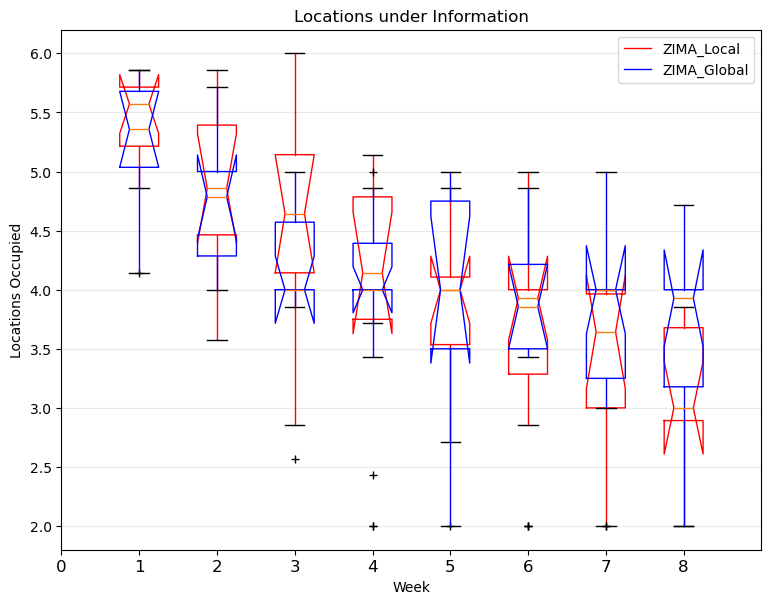

<Figure size 640x480 with 0 Axes>

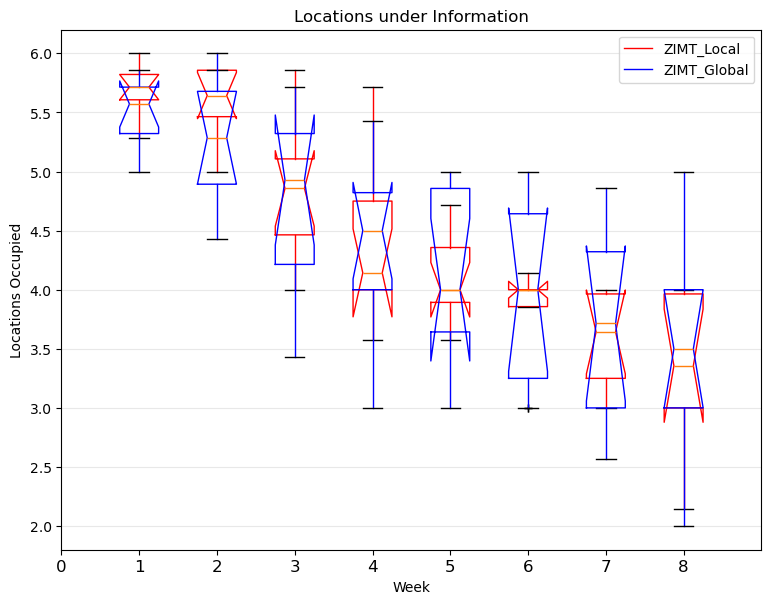

<Figure size 640x480 with 0 Axes>

In [8]:
# ZIMA Search
ag_class = 'ZIMA'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zima_loc_df, zima_loc_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zima_loc_al_df = dm_res_helpers.add_all_metrics(zima_loc_df, zima_loc_per_df)

ag_class = 'ZIMA'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zima_glob_df, zima_glob_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=True, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zima_glob_al_df = dm_res_helpers.add_all_metrics(zima_glob_df, zima_glob_per_df)

# ZIMT Search
ag_class = 'ZIMT'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zimt_loc_df, zimt_loc_per_df = dm_sim.make_monte_carlo(sim_name='ZIDT_test',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zimt_loc_al_df = dm_res_helpers.add_all_metrics(zimt_loc_df, zimt_loc_per_df)

ag_class = 'ZIMT'
strategy_params = None # Using default params
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

zimt_glob_df, zimt_glob_per_df = dm_sim.make_monte_carlo(sim_name='zimt_glob',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=True, 
                bargain_history_locations=False,
                bargain_history_duration=0,
                
                return_df=True, return_period_df=True,
                print_params=False)

zimt_glob_al_df = dm_res_helpers.add_all_metrics(zimt_glob_df, zimt_glob_per_df)

# Comparison of efficiencies
zima_loc_eff = nb_helpers.format_df_for_boxplot(zima_loc_al_df, 'week', 'week_eff')
zima_glob_eff = nb_helpers.format_df_for_boxplot(zima_glob_al_df, 'week', 'week_eff')
zimt_loc_eff = nb_helpers.format_df_for_boxplot(zimt_loc_al_df, 'week', 'week_eff')
zimt_glob_eff = nb_helpers.format_df_for_boxplot(zimt_glob_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [zima_loc_eff, zima_glob_eff]
ttl = "Efficiencies under Information"
labs = ["ZIMA_Local", "ZIMA_Global"]

ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue']
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

box_dt = [zimt_loc_eff, zimt_glob_eff]
labs = ["ZIMT_Local", "ZIMT_Global"]
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
zima_loc_loc = nb_helpers.format_df_for_boxplot(zima_loc_al_df, 'week', 'week_loc_occupied')
zima_glob_loc = nb_helpers.format_df_for_boxplot(zima_glob_al_df, 'week', 'week_loc_occupied')
zimt_loc_loc = nb_helpers.format_df_for_boxplot(zimt_loc_al_df, 'week', 'week_loc_occupied')
zimt_glob_loc = nb_helpers.format_df_for_boxplot(zimt_glob_al_df, 'week', 'week_loc_occupied')

box_dt = [zima_loc_loc, zima_glob_loc]
ttl = "Locations under Information"
ylab = "Locations Occupied"
labs = ["ZIMA_Local", "ZIMA_Global"]
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

box_dt = [zimt_loc_loc, zimt_glob_loc]
labs = ["ZIMT_Local", "ZIMT_Global"]
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)


# FLATTEN BUYERS OR SELLERS

In [10]:
# Base Inputs
ag_names = ['Buyer_1', 'Buyer_2', 'Buyer_3', 
            'Seller_1', 'Seller_2', 'Seller_3']
ag_n = 1; ag_types = ['BUYER']*3+['SELLER']*3
base_lb = [200, 300, 400, 200, 300, 400] 
base_ub = [600, 700, 800, 600, 700, 800]
ag_nu = 8; 
ag_end = [500]*3+[0]*3; ag_pf = None
ag_me = 0; ag_loc = None

# Flat Buyers
flat_b_lb = [200, 300, 400, 200, 300, 400] 
flat_b_ub = [400, 500, 600, 600, 700, 800]

# Flat Sellers
flat_s_lb = [200, 300, 400, 200, 300, 400] 
flat_s_ub = [600, 700, 800, 400, 500, 600]

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

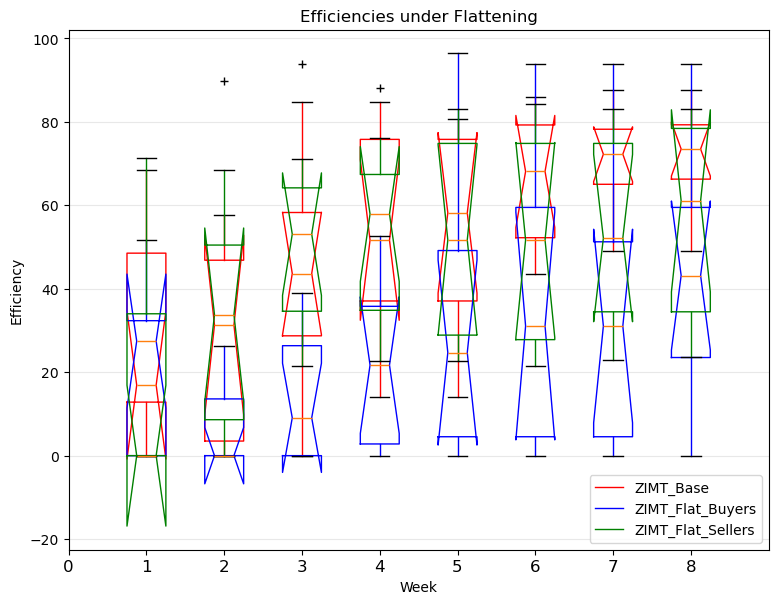

<Figure size 640x480 with 0 Axes>

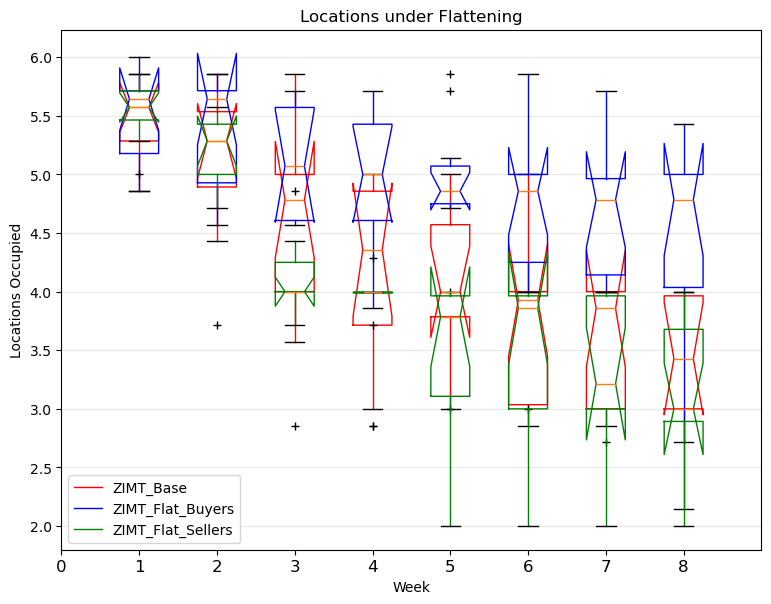

<Figure size 640x480 with 0 Axes>

In [18]:
# ZIMT Search
ag_class = 'ZIMT'
ag_desc = 'ZIMT'
strategy_params = None # Using default params
bh_dur = 0

# Base
ag_lb = base_lb
ag_ub = base_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

base_df, base_per_df = dm_sim.make_monte_carlo(sim_name='base',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

base_al_df = dm_res_helpers.add_all_metrics(base_df, base_per_df)

# 2xBuyers
ag_lb = flat_b_lb
ag_ub = flat_b_ub

ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fbuy_df, fbuy_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fbuy_al_df = dm_res_helpers.add_all_metrics(fbuy_df, fbuy_per_df)

# 2x Sellers
ag_lb = flat_s_lb
ag_ub = flat_s_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fsel_df, fsel_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fsel_al_df = dm_res_helpers.add_all_metrics(fsel_df, fsel_per_df)

# Comparison of efficiencies
base_eff = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_eff')
fbuy_eff = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_eff')
fsel_eff = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [base_eff, fbuy_eff, fsel_eff]
ttl = "Efficiencies under Flattening"
labs = [f"{ag_desc}_Base", f"{ag_desc}_Flat_Buyers", f"{ag_desc}_Flat_Sellers"]

ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue', 'green']
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
base_loc = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_loc_occupied')
fbuy_loc = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_loc_occupied')
fsel_loc = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_loc_occupied')

box_dt = [base_loc, fbuy_loc, fsel_loc]
ttl = "Locations under Flattening"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

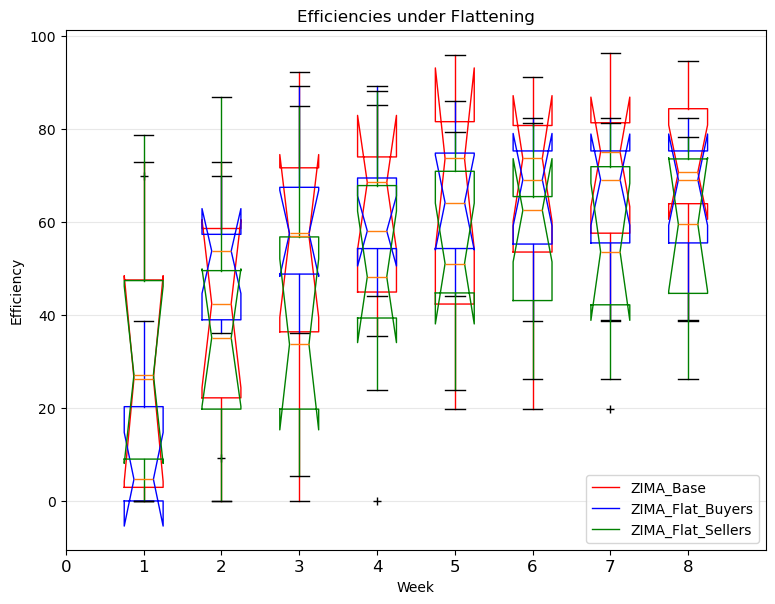

<Figure size 640x480 with 0 Axes>

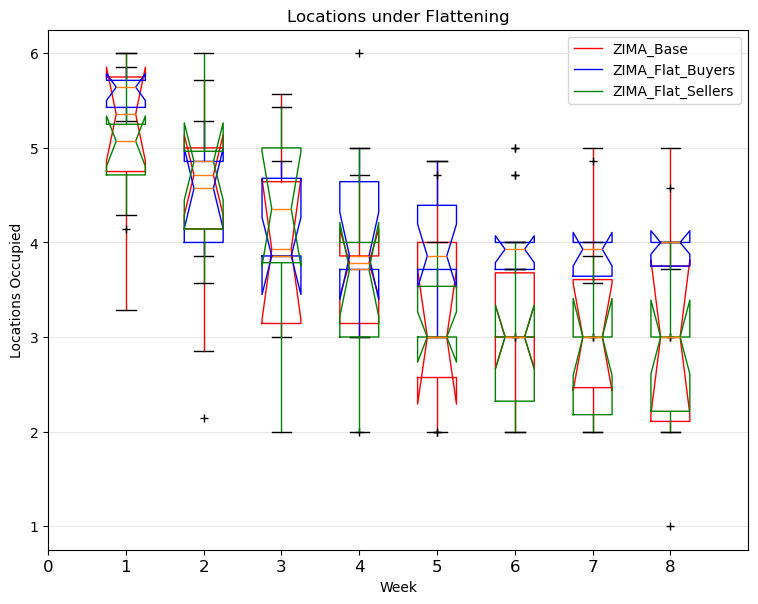

<Figure size 640x480 with 0 Axes>

In [19]:
# ZIMA Search
ag_class = 'ZIMA'
ag_desc = 'ZIMA'
strategy_params = None # Using default params
bh_dur = 0

# Base
ag_lb = base_lb
ag_ub = base_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

base_df, base_per_df = dm_sim.make_monte_carlo(sim_name='base',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

base_al_df = dm_res_helpers.add_all_metrics(base_df, base_per_df)

# 2xBuyers
ag_lb = flat_b_lb
ag_ub = flat_b_ub

ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fbuy_df, fbuy_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fbuy_al_df = dm_res_helpers.add_all_metrics(fbuy_df, fbuy_per_df)

# 2x Sellers
ag_lb = flat_s_lb
ag_ub = flat_s_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fsel_df, fsel_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fsel_al_df = dm_res_helpers.add_all_metrics(fsel_df, fsel_per_df)

# Comparison of efficiencies
base_eff = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_eff')
fbuy_eff = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_eff')
fsel_eff = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [base_eff, fbuy_eff, fsel_eff]
ttl = "Efficiencies under Flattening"
labs = [f"{ag_desc}_Base", f"{ag_desc}_Flat_Buyers", f"{ag_desc}_Flat_Sellers"]

ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue', 'green']
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
base_loc = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_loc_occupied')
fbuy_loc = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_loc_occupied')
fsel_loc = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_loc_occupied')

box_dt = [base_loc, fbuy_loc, fsel_loc]
ttl = "Locations under Flattening"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

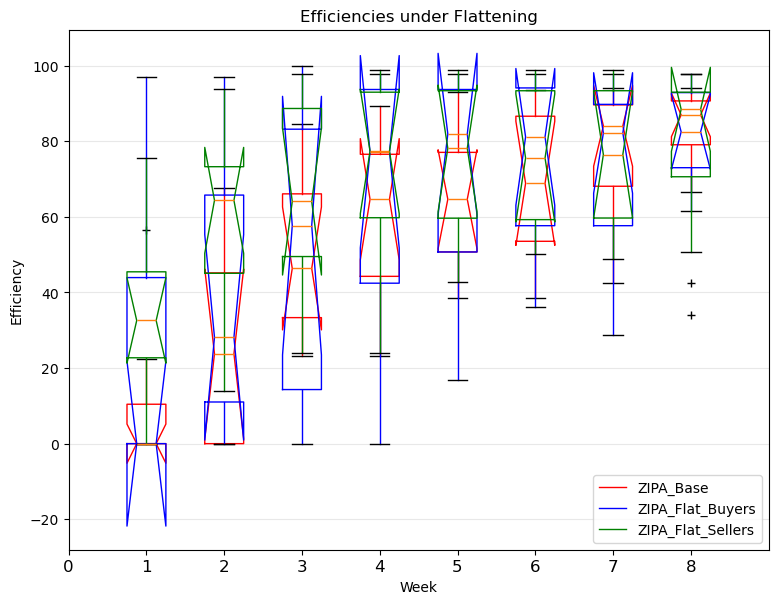

<Figure size 640x480 with 0 Axes>

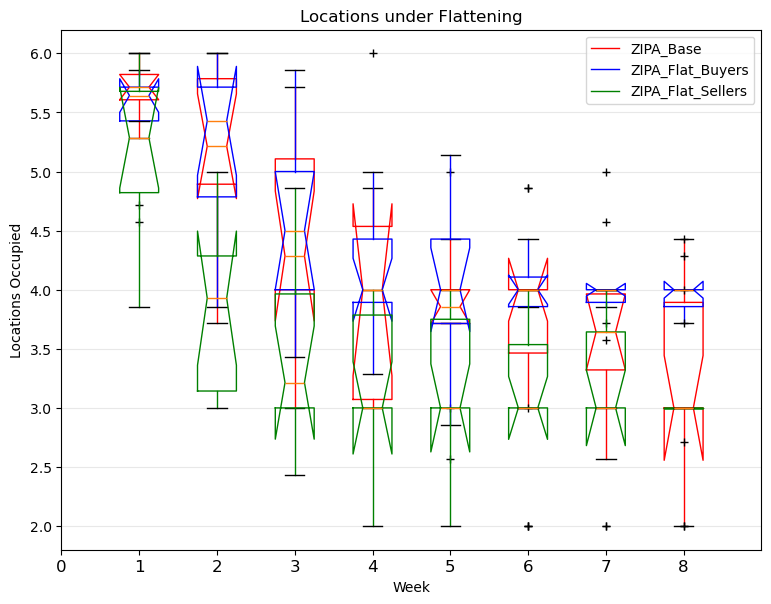

<Figure size 640x480 with 0 Axes>

In [24]:
# ZIPA Search
ag_class = 'ZIDPA'
ag_desc = 'ZIPA'
strategy_params = None # Using default params
bh_dur = -1

# Base
ag_lb = base_lb
ag_ub = base_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

base_df, base_per_df = dm_sim.make_monte_carlo(sim_name='base',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

base_al_df = dm_res_helpers.add_all_metrics(base_df, base_per_df)

# 2xBuyers
ag_lb = flat_b_lb
ag_ub = flat_b_ub

ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fbuy_df, fbuy_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fbuy_al_df = dm_res_helpers.add_all_metrics(fbuy_df, fbuy_per_df)

# 2x Sellers
ag_lb = flat_s_lb
ag_ub = flat_s_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fsel_df, fsel_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fsel_al_df = dm_res_helpers.add_all_metrics(fsel_df, fsel_per_df)

# Comparison of efficiencies
base_eff = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_eff')
fbuy_eff = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_eff')
fsel_eff = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [base_eff, fbuy_eff, fsel_eff]
ttl = "Efficiencies under Flattening"
labs = [f"{ag_desc}_Base", f"{ag_desc}_Flat_Buyers", f"{ag_desc}_Flat_Sellers"]

ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue', 'green']
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
base_loc = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_loc_occupied')
fbuy_loc = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_loc_occupied')
fsel_loc = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_loc_occupied')

box_dt = [base_loc, fbuy_loc, fsel_loc]
ttl = "Locations under Flattening"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/alex/anaconda3/envs/dm_markets/lib/python3.11/site-packages/pandas/core/algorithms.py:1814: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Us

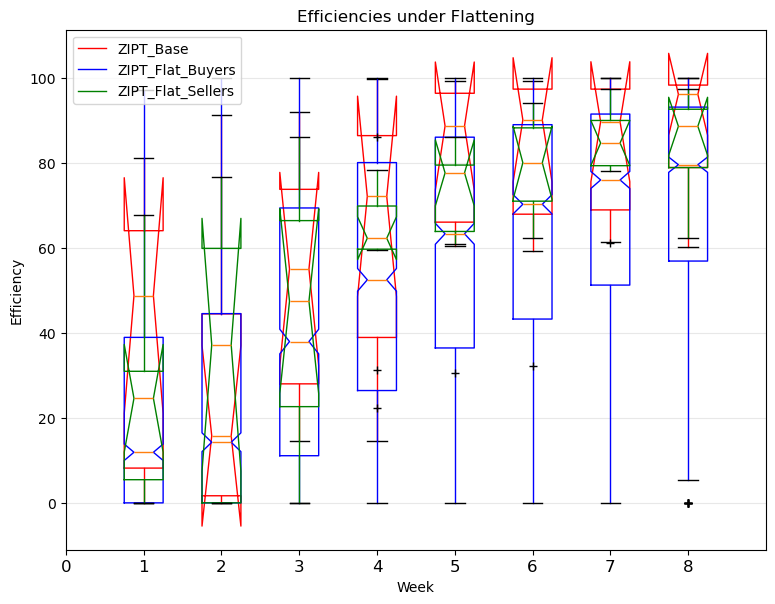

<Figure size 640x480 with 0 Axes>

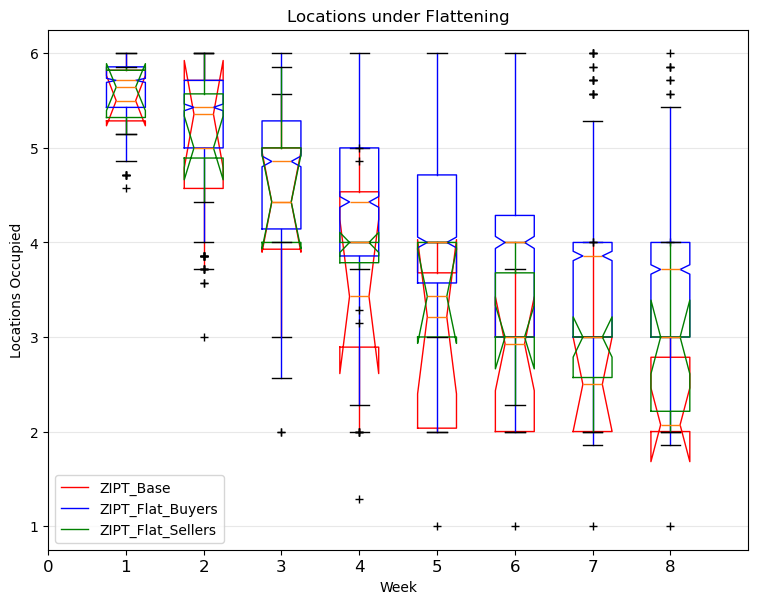

<Figure size 640x480 with 0 Axes>

In [26]:
# ZIPT Search
ag_class = 'ZIPT'
ag_desc = 'ZIPT'
strategy_params = None # Using default params
bh_dur = -1

# Base
ag_lb = base_lb
ag_ub = base_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

base_df, base_per_df = dm_sim.make_monte_carlo(sim_name='base',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

base_al_df = dm_res_helpers.add_all_metrics(base_df, base_per_df)

# 2xBuyers
ag_lb = flat_b_lb
ag_ub = flat_b_ub

ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fbuy_df, fbuy_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=1000,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fbuy_al_df = dm_res_helpers.add_all_metrics(fbuy_df, fbuy_per_df)

# 2x Sellers
ag_lb = flat_s_lb
ag_ub = flat_s_ub
ag_groups, _ = dm_utils.gen_agent_groups(ag_n, ag_types, ag_class, strategy_params, ag_lb, ag_ub, ag_nu, ag_end, ag_pf, ag_me, ag_loc, return_names=True)

fsel_df, fsel_per_df = dm_sim.make_monte_carlo(sim_name='flat_buyer',
                                             num_trials=10,
                num_weeks=8, 
                num_periods=7,
                num_rounds=5, 
                num_traders=6,
                agent_groups=ag_groups,
                group_names=ag_names,
                grid_size=6, # TODO: Deprecate this behavior - need to actually provide a value here - used in Travel institution
                
                bargain_round_broadcasts=False, 
                bargain_history_global=False, 
                bargain_history_locations=False,
                bargain_history_duration=bh_dur,
                
                return_df=True, return_period_df=True,
                print_params=False)

fsel_al_df = dm_res_helpers.add_all_metrics(fsel_df, fsel_per_df)

# Comparison of efficiencies
base_eff = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_eff')
fbuy_eff = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_eff')
fsel_eff = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_eff')

# Plot the boxplot data
box_dt = [base_eff, fbuy_eff, fsel_eff]
ttl = "Efficiencies under Flattening"
labs = [f"{ag_desc}_Base", f"{ag_desc}_Flat_Buyers", f"{ag_desc}_Flat_Sellers"]

ylab = "Efficiency"
xlab = "Week"

xmax = 8
incr = 1
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)
crls = ['red', 'blue', 'green']
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)

# Comparison of locations occupied
base_loc = nb_helpers.format_df_for_boxplot(base_al_df, 'week', 'week_loc_occupied')
fbuy_loc = nb_helpers.format_df_for_boxplot(fbuy_al_df, 'week', 'week_loc_occupied')
fsel_loc = nb_helpers.format_df_for_boxplot(fsel_al_df, 'week', 'week_loc_occupied')

box_dt = [base_loc, fbuy_loc, fsel_loc]
ttl = "Locations under Flattening"
ylab = "Locations Occupied"
nb_helpers.plot_boxplot_data(box_dt, 
                             title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm,
                             n=len(crls),
                             colors=crls)